# P2P-GeoThreatAtlas — аналитический итоговый ноутбук

**Тема ВКР:** «Моделирование и визуализация угроз в мобильных P2P-сетях на базе геоданных»  
**Репозиторий:** [https://github.com/cryptoinsider1/p2p-geothreat-atlas](https://github.com/cryptoinsider1/p2p-geothreat-atlas)  
**Версия ноутбука:** `v0.5-analytical`  
**Назначение:** не только вывести CSV/PNG, но и интерпретировать результаты через baseline-норму, дельты, проверку ожидаемых эффектов, светофор рисков и сравнение чувствительности `radius` vs `k-NN`.

Этот ноутбук можно использовать как:
1. техническую проверку воспроизводимости;
2. визуальный отчёт по экспериментам;
3. аналитическую «панель врача»: baseline = внутренняя норма, сценарии угроз = отклонения от нормы;
4. источник формулировок для текста ВКР.


## 0. Логика анализа

В работе нет внешней «таблицы нормальных значений», как в медицинских анализах. Поэтому норму задаём **внутри эксперимента**:

> **Baseline** — контрольное состояние сети.  
> **Threat scenario** — воздействие угрозы.  
> **Delta** — отклонение метрики от baseline.  
> **Interpretation** — инженерный смысл отклонения.

Интерпретационная конструкция строится на четырёх слоях:

| Слой | Что делает |
|---|---|
| 1. Сырые метрики | Показывает таблицы `summary_metrics.csv` |
| 2. Дельты от baseline | Показывает абсолютные и процентные изменения |
| 3. Проверка ожидаемых эффектов | Проверяет, действительно ли сценарии проявились в метриках |
| 4. Диагностический светофор | Даёт краткий вывод: зелёный / жёлтый / красный и причину |

Важно: светофор не является ML-классификатором. Это прозрачная rule-based интерпретация, полезная для ВКР и инженерной проверки прототипа.


In [1]:
from __future__ import annotations

import os
import sys
import math
import json
import subprocess
from pathlib import Path
from typing import Iterable, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image, Markdown, HTML, display

# ========= Параметры ноутбука =========

PROJECT_TITLE = "P2P-GeoThreatAtlas"
REPO_URL = "https://github.com/cryptoinsider1/p2p-geothreat-atlas"
NOTEBOOK_VERSION = "v0.5-analytical"

GRAPH_TYPES = ["radius", "knn"]
SCENARIOS = ["baseline", "rogue", "flooding", "isolation", "spoofing"]

# Автозапуск недостающих plane-результатов.
AUTO_RUN_MISSING = True

# Geo-результаты могут быть тяжелее/дольше и зависят от принятого bbox.
# По умолчанию geo анализируется, если outputs/geo уже есть.
# Если нужно генерировать geo автоматически — поменять на True.
RUN_GEO_IF_MISSING = False

# Для финальной версии ВКР обычно достаточно 10 прогонов.
STABILITY_RUNS = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)

def detect_project_root() -> Path:
    """Определяет корень проекта при запуске из корня, notebooks/ или вложенной рабочей директории."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for p in candidates:
        if (p / "src").exists() or (p / "outputs").exists() or (p / "notebooks").exists():
            return p
    return cwd

project_root = detect_project_root()
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if (project_root / "src").exists() and str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

print(f"Project: {PROJECT_TITLE}")
print(f"Version: {NOTEBOOK_VERSION}")
print(f"Project root: {project_root}")
print(f"Python: {sys.executable}")


Project: P2P-GeoThreatAtlas
Version: v0.5-analytical
Project root: /Users/vladimir/Desktop/vkr
Python: /Users/vladimir/Desktop/vkr/venv/bin/python


## 1. Подготовка и запуск экспериментов

Ноутбук умеет работать в двух режимах:

| Режим | Папка результатов | Смысл |
|---|---|---|
| `plane` | `outputs/` | условная координатная плоскость `[0, 100]` |
| `geo` | `outputs/geo/` | реальные координаты, `x = lon`, `y = lat`, расстояние через haversine |

Если CSV уже существуют, повторная генерация пропускается. Если plane-результаты отсутствуют, ноутбук попробует их сгенерировать. Geo-результаты автоматически не генерируются, если `RUN_GEO_IF_MISSING = False`.


In [2]:
def coord_root(coord: str) -> Path:
    if coord == "plane":
        return project_root / "outputs"
    if coord == "geo":
        return project_root / "outputs" / "geo"
    raise ValueError(f"Unknown coord mode: {coord}")

def summary_path(coord: str, graph: str) -> Path:
    return coord_root(coord) / "tables" / graph / "summary_metrics.csv"

def stability_path(coord: str) -> Path:
    return coord_root(coord) / "tables" / "stability_metrics.csv"

def boxplot_path(coord: str) -> Path:
    return coord_root(coord) / "figures" / "stability_boxplots.png"

def figure_path(coord: str, graph: str, scenario: str) -> Path:
    return coord_root(coord) / "figures" / graph / f"{scenario}_after.png"

def map_path(coord: str, graph: str, scenario: str) -> Path:
    return coord_root(coord) / "maps" / graph / f"{scenario}_map.html"

def find_script(name: str) -> Path | None:
    candidates = [project_root / "src" / name, project_root / name]
    return next((p for p in candidates if p.exists()), None)

def run_cmd(cmd: list[str], desc: str = "") -> int:
    if desc:
        print(f"\n==> {desc}")
    print(" ".join(cmd))
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        print(f"[WARNING] Команда завершилась с кодом {result.returncode}")
    return result.returncode

def run_experiments_for_coord(coord: str) -> None:
    """Пытается сгенерировать результаты для coord."""
    script = find_script("run_experiment.py")
    if script is None:
        print("[SKIP] run_experiment.py не найден")
        return

    rc = run_cmd(
        [sys.executable, str(script), "--all-graphs", "--coord", coord],
        f"Run all graph experiments for coord={coord}",
    )

    if rc != 0:
        print("[INFO] Пробую fallback-запуск по отдельным графам.")
        for graph in GRAPH_TYPES:
            run_cmd(
                [sys.executable, str(script), "-g", graph, "--coord", coord],
                f"Run {graph} graph for coord={coord}",
            )

def run_stability_for_coord(coord: str) -> None:
    script = find_script("run_multi_seed.py")
    if script is None:
        print("[SKIP] run_multi_seed.py не найден")
        return

    rc = run_cmd(
        [sys.executable, str(script), "--runs", str(STABILITY_RUNS), "--coord", coord, "--graphs", "radius", "knn"],
        f"Run stability analysis for coord={coord}",
    )

    if rc != 0:
        print("[WARNING] Stability run failed. Блок устойчивости будет пропущен или построен по существующим файлам.")

def ensure_outputs() -> list[str]:
    """Определяет доступные режимы координат и при необходимости генерирует plane."""
    plane_missing = not all(summary_path("plane", g).exists() for g in GRAPH_TYPES)
    if plane_missing and AUTO_RUN_MISSING:
        run_experiments_for_coord("plane")

    if not stability_path("plane").exists() and AUTO_RUN_MISSING:
        run_stability_for_coord("plane")

    geo_missing = not all(summary_path("geo", g).exists() for g in GRAPH_TYPES)
    if geo_missing and RUN_GEO_IF_MISSING:
        run_experiments_for_coord("geo")
        if not stability_path("geo").exists():
            run_stability_for_coord("geo")

    available = []
    for coord in ["plane", "geo"]:
        if any(summary_path(coord, g).exists() for g in GRAPH_TYPES):
            available.append(coord)

    return available

AVAILABLE_COORDS = ensure_outputs()

if not AVAILABLE_COORDS:
    print("[WARNING] Не найдено ни одного набора результатов. Проверьте запуск run_experiment.py.")
else:
    print("\nДоступные режимы анализа:", ", ".join(AVAILABLE_COORDS))
    for coord in AVAILABLE_COORDS:
        for graph in GRAPH_TYPES:
            print(f"{coord}/{graph}: {summary_path(coord, graph).exists()} -> {summary_path(coord, graph).relative_to(project_root)}")
        print(f"{coord}/stability: {stability_path(coord).exists()} -> {stability_path(coord).relative_to(project_root)}")



Доступные режимы анализа: plane, geo
plane/radius: True -> outputs/tables/radius/summary_metrics.csv
plane/knn: True -> outputs/tables/knn/summary_metrics.csv
plane/stability: True -> outputs/tables/stability_metrics.csv
geo/radius: True -> outputs/geo/tables/radius/summary_metrics.csv
geo/knn: True -> outputs/geo/tables/knn/summary_metrics.csv
geo/stability: True -> outputs/geo/tables/stability_metrics.csv


## 2. Загрузка данных

Здесь загружаются таблицы метрик по всем найденным режимам координат и типам графов.


In [3]:
def read_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    return df

def read_optional_csv(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

def scenario_column(df: pd.DataFrame, scenario: str) -> str | None:
    target = scenario.lower()
    for col in df.columns:
        if str(col).lower() == target:
            return col
    return None

def metric_value(df: pd.DataFrame, scenario: str, metric: str, default: float = np.nan) -> float:
    col = scenario_column(df, scenario)
    if col is None or metric not in df.index:
        return default
    try:
        return float(df.loc[metric, col])
    except Exception:
        return default

summaries: dict[tuple[str, str], pd.DataFrame] = {}
stability_tables: dict[str, pd.DataFrame] = {}

for coord in AVAILABLE_COORDS:
    for graph in GRAPH_TYPES:
        p = summary_path(coord, graph)
        if p.exists():
            summaries[(coord, graph)] = read_summary(p)
            print(f"Loaded: {p.relative_to(project_root)}")
    st = stability_path(coord)
    if st.exists():
        stability_tables[coord] = read_optional_csv(st)
        print(f"Loaded: {st.relative_to(project_root)}")

print("\nИтого summary tables:", len(summaries))
print("Итого stability tables:", len(stability_tables))


Loaded: outputs/tables/radius/summary_metrics.csv
Loaded: outputs/tables/knn/summary_metrics.csv
Loaded: outputs/tables/stability_metrics.csv
Loaded: outputs/geo/tables/radius/summary_metrics.csv
Loaded: outputs/geo/tables/knn/summary_metrics.csv
Loaded: outputs/geo/tables/stability_metrics.csv

Итого summary tables: 4
Итого stability tables: 2


## 3. Словарь метрик и интерпретационная рамка

Эта таблица задаёт «смысловые нормы» для анализа.  
Она не заменяет математические метрики, а помогает связать числа с инженерным выводом.


In [4]:
METRIC_CATALOG = pd.DataFrame([
    {"metric": "nodes", "category": "масштаб сети", "baseline_norm": "обычно стабильно", "increase_meaning": "появление дополнительных/подставных узлов", "decrease_meaning": "потеря узлов или фильтрация"},
    {"metric": "edges", "category": "связность", "baseline_norm": "зависит от модели графа", "increase_meaning": "усиление/искусственное расширение связей", "decrease_meaning": "разрыв связей, изоляция, деградация топологии"},
    {"metric": "density", "category": "плотность", "baseline_norm": "внутренняя норма относительно baseline", "increase_meaning": "граф становится плотнее, возможна ложная связность", "decrease_meaning": "граф редеет, повышается риск фрагментации"},
    {"metric": "avg_degree", "category": "средняя степень", "baseline_norm": "внутренняя норма относительно baseline", "increase_meaning": "больше средних соседей, возможна инъекция связности", "decrease_meaning": "меньше связей, ухудшение доступности"},
    {"metric": "num_components", "category": "компоненты связности", "baseline_norm": "контрольное число компонент", "increase_meaning": "фрагментация сети", "decrease_meaning": "искусственное объединение ранее раздельных частей сети"},
    {"metric": "largest_component_size", "category": "крупнейшая компонента", "baseline_norm": "размер основной связной области", "increase_meaning": "укрупнение связного ядра", "decrease_meaning": "распад основной компоненты"},
    {"metric": "isolated_nodes", "category": "изолированные узлы", "baseline_norm": "чем меньше, тем устойчивее", "increase_meaning": "потеря доступности узлов", "decrease_meaning": "снижение изоляции"},
    {"metric": "max_degree_centrality", "category": "локальная центральность", "baseline_norm": "контрольный максимум", "increase_meaning": "появление чрезмерно влиятельного узла", "decrease_meaning": "снижение концентрации связей"},
    {"metric": "max_betweenness_centrality", "category": "посредническая центральность", "baseline_norm": "контрольный максимум", "increase_meaning": "узел становится критическим мостом", "decrease_meaning": "меньше зависимости от одного посредника"},
    {"metric": "total_load", "category": "нагрузка", "baseline_norm": "обычно 0 в синтетическом baseline", "increase_meaning": "рост сетевой активности/нагрузочной атаки", "decrease_meaning": "нормализация нагрузки"},
    {"metric": "load_anomaly_count", "category": "аномальная нагрузка", "baseline_norm": "0", "increase_meaning": "обнаружены flooder-узлы", "decrease_meaning": "снижение числа аномалий"},
])

display(METRIC_CATALOG)


,metric,category,baseline_norm,increase_meaning,decrease_meaning
0,nodes,масштаб сети,обычно стабильно,появление дополнительных/подставных узлов,потеря узлов или фильтрация
1,edges,связность,зависит от модели графа,усиление/искусственное расширение связей,"разрыв связей, изоляция, деградация топологии"
2,density,плотность,внутренняя норма относительно baseline,"граф становится плотнее, возможна ложная связн...","граф редеет, повышается риск фрагментации"
3,avg_degree,средняя степень,внутренняя норма относительно baseline,"больше средних соседей, возможна инъекция связ...","меньше связей, ухудшение доступности"
4,num_components,компоненты связности,контрольное число компонент,фрагментация сети,искусственное объединение ранее раздельных час...
5,largest_component_size,крупнейшая компонента,размер основной связной области,укрупнение связного ядра,распад основной компоненты
6,isolated_nodes,изолированные узлы,"чем меньше, тем устойчивее",потеря доступности узлов,снижение изоляции
7,max_degree_centrality,локальная центральность,контрольный максимум,появление чрезмерно влиятельного узла,снижение концентрации связей
8,max_betweenness_centrality,посредническая центральность,контрольный максимум,узел становится критическим мостом,меньше зависимости от одного посредника
9,total_load,нагрузка,обычно 0 в синтетическом baseline,рост сетевой активности/нагрузочной атаки,нормализация нагрузки


## 4. Сырые сводные таблицы

Это базовый слой: что именно было посчитано экспериментами.


In [5]:
for (coord, graph), df in summaries.items():
    display(Markdown(f"### {coord.upper()} / {graph.upper()} — summary metrics"))
    display(df)


### PLANE / RADIUS — summary metrics

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,82.0000,96.0000,82.0000,77.0000,87.0000
density,0.0669,0.0784,0.0669,0.0629,0.0682
avg_degree,3.2800,3.8400,3.2800,3.0800,3.4118
num_components,7.0000,3.0000,7.0000,10.0000,6.0000
largest_component_size,34.0000,41.0000,34.0000,18.0000,38.0000
isolated_nodes,2.0000,0.0000,2.0000,4.0000,2.0000
avg_clustering,0.5169,0.6065,0.5169,0.4609,0.4832
max_degree_centrality,0.1633,0.2857,0.1633,0.1633,0.1600
max_betweenness_centrality,0.2568,0.4413,0.2568,0.0408,0.2629


### PLANE / KNN — summary metrics

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,150.0000,159.0000,150.0000,132.0000,155.0000
density,0.1224,0.1298,0.1224,0.1078,0.1216
avg_degree,6.0000,6.3600,6.0000,5.2800,6.0784
num_components,1.0000,1.0000,1.0000,4.0000,1.0000
largest_component_size,50.0000,50.0000,50.0000,47.0000,51.0000
isolated_nodes,0.0000,0.0000,0.0000,3.0000,0.0000
avg_clustering,0.6373,0.6523,0.6373,0.5978,0.6094
max_degree_centrality,0.1837,0.2857,0.1837,0.1837,0.1800
max_betweenness_centrality,0.2641,0.2581,0.2641,0.2216,0.2320


### GEO / RADIUS — summary metrics

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,23.0000,28.0000,23.0000,21.0000,28.0000
density,0.0188,0.0229,0.0188,0.0171,0.0220
avg_degree,0.9200,1.1200,0.9200,0.8400,1.0980
num_components,29.0000,24.0000,29.0000,31.0000,25.0000
largest_component_size,7.0000,8.0000,7.0000,7.0000,15.0000
isolated_nodes,19.0000,14.0000,19.0000,22.0000,18.0000
avg_clustering,0.0933,0.0933,0.0933,0.0933,0.0784
max_degree_centrality,0.0612,0.1020,0.0612,0.0612,0.1000
max_betweenness_centrality,0.0094,0.0153,0.0094,0.0094,0.0604


### GEO / KNN — summary metrics

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,151.0000,151.0000,151.0000,132.0000,156.0000
density,0.1233,0.1233,0.1233,0.1078,0.1224
avg_degree,6.0400,6.0400,6.0400,5.2800,6.1176
num_components,1.0000,1.0000,1.0000,4.0000,1.0000
largest_component_size,50.0000,50.0000,50.0000,47.0000,51.0000
isolated_nodes,0.0000,0.0000,0.0000,3.0000,0.0000
avg_clustering,0.6414,0.6414,0.6414,0.5979,0.6130
max_degree_centrality,0.1837,0.1837,0.1837,0.1837,0.1800
max_betweenness_centrality,0.2634,0.2634,0.2634,0.2241,0.2176


## 5. Дельты от baseline

Здесь появляется то, чего не хватало обычной таблице: не просто значения, а **отклонения от контрольного состояния**.

- `delta` — абсолютное изменение;
- `pct_delta` — процентное изменение относительно baseline;
- `direction` — направление изменения.


In [6]:
KEY_METRICS = [
    "nodes", "edges", "density", "avg_degree",
    "num_components", "largest_component_size", "isolated_nodes",
    "avg_clustering", "max_degree_centrality", "max_betweenness_centrality",
    "total_load", "max_load", "avg_load", "load_std", "load_anomaly_count",
]

def safe_pct_delta(value: float, base: float) -> float:
    if pd.isna(value) or pd.isna(base) or abs(base) < 1e-12:
        return np.nan
    return (value - base) / abs(base) * 100.0

def build_delta_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for scenario in SCENARIOS:
        if scenario == "baseline":
            continue
        if scenario_column(df, scenario) is None:
            continue

        for metric in KEY_METRICS:
            if metric not in df.index:
                continue
            base = metric_value(df, "baseline", metric)
            value = metric_value(df, scenario, metric)
            delta = value - base if not (pd.isna(value) or pd.isna(base)) else np.nan
            pct = safe_pct_delta(value, base)
            if pd.isna(delta):
                direction = "n/a"
            elif abs(delta) < 1e-12:
                direction = "без изменений"
            elif delta > 0:
                direction = "рост"
            else:
                direction = "снижение"

            rows.append({
                "scenario": scenario,
                "metric": metric,
                "baseline": base,
                "value": value,
                "delta": delta,
                "pct_delta": pct,
                "direction": direction,
            })
    return pd.DataFrame(rows)

delta_tables: dict[tuple[str, str], pd.DataFrame] = {}

for key, df in summaries.items():
    coord, graph = key
    dt = build_delta_table(df)
    delta_tables[key] = dt

    display(Markdown(f"### {coord.upper()} / {graph.upper()} — абсолютные дельты"))
    if not dt.empty:
        pivot_abs = dt.pivot(index="metric", columns="scenario", values="delta")
        display(pivot_abs.loc[[m for m in KEY_METRICS if m in pivot_abs.index]])

        display(Markdown(f"### {coord.upper()} / {graph.upper()} — процентные дельты, %"))
        pivot_pct = dt.pivot(index="metric", columns="scenario", values="pct_delta")
        display(pivot_pct.loc[[m for m in KEY_METRICS if m in pivot_pct.index]])
    else:
        print("Delta table is empty.")


### PLANE / RADIUS — абсолютные дельты

scenario,flooding,isolation,rogue,spoofing
metric,,,,
nodes,0.0000,0.0000,0.0000,1.0000
edges,0.0000,-5.0000,14.0000,5.0000
density,0.0000,-0.0041,0.0114,0.0013
avg_degree,0.0000,-0.2000,0.5600,0.1318
num_components,0.0000,3.0000,-4.0000,-1.0000
largest_component_size,0.0000,-16.0000,7.0000,4.0000
isolated_nodes,0.0000,2.0000,-2.0000,0.0000
avg_clustering,0.0000,-0.0560,0.0896,-0.0337
max_degree_centrality,0.0000,0.0000,0.1224,-0.0033


### PLANE / RADIUS — процентные дельты, %

scenario,flooding,isolation,rogue,spoofing
metric,,,,
nodes,0.0000,0.0000,0.0000,2.0000
edges,0.0000,-6.0976,17.0732,6.0976
density,0.0000,-6.0976,17.0732,1.9369
avg_degree,0.0000,-6.0976,17.0732,4.0172
num_components,0.0000,42.8571,-57.1429,-14.2857
largest_component_size,0.0000,-47.0588,20.5882,11.7647
isolated_nodes,0.0000,100.0000,-100.0000,0.0000
avg_clustering,0.0000,-10.8337,17.3419,-6.5128
max_degree_centrality,0.0000,0.0000,75.0000,-2.0000


### PLANE / KNN — абсолютные дельты

...

scenario,flooding,isolation,rogue,spoofing
metric,,,,
nodes,0.0000,0.0000,0.0000,2.0000
edges,0.0000,-8.6957,21.7391,21.7391
density,0.0000,-8.6957,21.7391,16.9650
avg_degree,0.0000,-8.6957,21.7391,19.3521
num_components,0.0000,6.8966,-17.2414,-13.7931
largest_component_size,0.0000,0.0000,14.2857,114.2857
isolated_nodes,0.0000,15.7895,-26.3158,-5.2632
avg_clustering,0.0000,0.0000,0.0000,-15.9664
max_degree_centrality,0.0000,0.0000,66.6667,63.3333


### GEO / KNN — абсолютные дельты

scenario,flooding,isolation,rogue,spoofing
metric,,,,
nodes,0.0000,0.0000,0.0000,1.0000
edges,0.0000,-19.0000,0.0000,5.0000
density,0.0000,-0.0155,0.0000,-0.0009
avg_degree,0.0000,-0.7600,0.0000,0.0776
num_components,0.0000,3.0000,0.0000,0.0000
largest_component_size,0.0000,-3.0000,0.0000,1.0000
isolated_nodes,0.0000,3.0000,0.0000,0.0000
avg_clustering,0.0000,-0.0435,0.0000,-0.0284
max_degree_centrality,0.0000,0.0000,0.0000,-0.0037


### GEO / KNN — процентные дельты, %

scenario,flooding,isolation,rogue,spoofing
metric,,,,
nodes,0.0000,0.0000,0.0000,2.0000
edges,0.0000,-12.5828,0.0000,3.3113
density,0.0000,-12.5828,0.0000,-0.7402
avg_degree,0.0000,-12.5828,0.0000,1.2855
num_components,0.0000,300.0000,0.0000,0.0000
largest_component_size,0.0000,-6.0000,0.0000,2.0000
isolated_nodes,NaN,NaN,NaN,NaN
avg_clustering,0.0000,-6.7785,0.0000,-4.4210
max_degree_centrality,0.0000,0.0000,0.0000,-2.0000


## 6. Диагностический светофор сценариев

Для каждого сценария строится прозрачная оценка:

| Сигнал | Пример |
|---|---|
| Фрагментация | `num_components ↑`, `largest_component_size ↓`, `isolated_nodes ↑` |
| Инъекция связности | `edges ↑`, `density ↑`, `num_components ↓`, centrality ↑ |
| Нагрузочная атака | `load_anomaly_count > 0`, `total_load ↑` |
| Подмена/появление узлов | `nodes ↑` |

Пороговая логика нужна для удобной инженерной подсказки.


In [7]:
def traffic_label(score: float) -> str:
    if score >= 60:
        return "КРАСНЫЙ"
    if score >= 25:
        return "ЖЁЛТЫЙ"
    return "ЗЕЛЁНЫЙ"

def fmt_pct(x: float) -> str:
    if pd.isna(x):
        return "—"
    return f"{x:+.1f}%"

def analyze_scenario(df: pd.DataFrame, scenario: str, coord: str, graph: str) -> dict[str, Any]:
    base_nodes = metric_value(df, "baseline", "nodes")
    nodes = metric_value(df, scenario, "nodes")
    nodes_delta = nodes - base_nodes

    base_edges = metric_value(df, "baseline", "edges")
    edges = metric_value(df, scenario, "edges")
    edges_pct = safe_pct_delta(edges, base_edges)

    base_density = metric_value(df, "baseline", "density")
    density = metric_value(df, scenario, "density")
    density_pct = safe_pct_delta(density, base_density)

    base_degree = metric_value(df, "baseline", "avg_degree")
    degree = metric_value(df, scenario, "avg_degree")
    degree_pct = safe_pct_delta(degree, base_degree)

    base_components = metric_value(df, "baseline", "num_components")
    components = metric_value(df, scenario, "num_components")
    components_delta = components - base_components

    base_lcc = metric_value(df, "baseline", "largest_component_size")
    lcc = metric_value(df, scenario, "largest_component_size")
    lcc_drop_pct = 0.0 if pd.isna(base_lcc) or abs(base_lcc) < 1e-12 else max(0.0, (base_lcc - lcc) / abs(base_lcc) * 100.0)

    base_isolated = metric_value(df, "baseline", "isolated_nodes")
    isolated = metric_value(df, scenario, "isolated_nodes")
    isolated_delta = isolated - base_isolated

    base_degree_cent = metric_value(df, "baseline", "max_degree_centrality")
    degree_cent = metric_value(df, scenario, "max_degree_centrality")
    degree_cent_pct = safe_pct_delta(degree_cent, base_degree_cent)

    base_between = metric_value(df, "baseline", "max_betweenness_centrality")
    between = metric_value(df, scenario, "max_betweenness_centrality")
    between_pct = safe_pct_delta(between, base_between)

    load_anomalies = metric_value(df, scenario, "load_anomaly_count", default=0.0)
    total_load = metric_value(df, scenario, "total_load", default=0.0)
    max_load = metric_value(df, scenario, "max_load", default=0.0)

    fragmentation_score = (
        max(0.0, components_delta) * 8.0 +
        max(0.0, isolated_delta) * 6.0 +
        lcc_drop_pct * 0.7
    )

    connectivity_injection_score = (
        max(0.0, edges_pct if not pd.isna(edges_pct) else 0.0) * 0.8 +
        max(0.0, density_pct if not pd.isna(density_pct) else 0.0) * 0.5 +
        max(0.0, degree_pct if not pd.isna(degree_pct) else 0.0) * 0.5 +
        (12.0 if components_delta < 0 else 0.0)
    )

    load_score = (
        max(0.0, load_anomalies) * 22.0 +
        (10.0 if total_load > 0 else 0.0) +
        (5.0 if max_load > 0 else 0.0)
    )

    identity_score = (
        max(0.0, nodes_delta) * 24.0 +
        max(0.0, edges_pct if not pd.isna(edges_pct) else 0.0) * 0.25
    )

    centrality_score = (
        max(0.0, degree_cent_pct if not pd.isna(degree_cent_pct) else 0.0) * 0.25 +
        max(0.0, between_pct if not pd.isna(between_pct) else 0.0) * 0.15
    )

    if scenario == "rogue":
        score = connectivity_injection_score + centrality_score
    elif scenario == "flooding":
        score = load_score
    elif scenario == "isolation":
        score = fragmentation_score
    elif scenario == "spoofing":
        score = identity_score + min(20.0, centrality_score)
    else:
        score = fragmentation_score + connectivity_injection_score + load_score + identity_score

    score = float(min(100.0, max(0.0, score)))

    signals = []
    if components_delta > 0:
        signals.append(f"компоненты +{components_delta:.0f}")
    if components_delta < 0:
        signals.append(f"компоненты {components_delta:.0f}")
    if lcc_drop_pct > 0:
        signals.append(f"LCC {lcc_drop_pct:.1f}%↓")
    if isolated_delta > 0:
        signals.append(f"изолированные узлы +{isolated_delta:.0f}")
    if not pd.isna(edges_pct) and abs(edges_pct) > 5:
        signals.append(f"рёбра {fmt_pct(edges_pct)}")
    if load_anomalies > 0:
        signals.append(f"аномалии нагрузки: {load_anomalies:.0f}")
    if nodes_delta > 0:
        signals.append(f"узлы +{nodes_delta:.0f}")
    if not pd.isna(degree_cent_pct) and degree_cent_pct > 10:
        signals.append(f"degree centrality {fmt_pct(degree_cent_pct)}")
    if not pd.isna(between_pct) and between_pct > 10:
        signals.append(f"betweenness {fmt_pct(between_pct)}")

    if not signals:
        signals.append("существенных отклонений не выявлено")

    if scenario == "rogue":
        diagnosis = "проверка ложной связности / чрезмерно влиятельных узлов"
    elif scenario == "flooding":
        diagnosis = "проверка нагрузочной аномалии без обязательного изменения топологии"
    elif scenario == "isolation":
        diagnosis = "проверка фрагментации и потери доступности"
    elif scenario == "spoofing":
        diagnosis = "проверка появления подставного участника и локального искажения связей"
    else:
        diagnosis = "общая проверка отклонения от baseline"

    return {
        "coord": coord,
        "graph_type": graph,
        "scenario": scenario,
        "risk_score": round(score, 2),
        "traffic": traffic_label(score),
        "diagnosis": diagnosis,
        "key_signals": "; ".join(signals),
        "nodes_delta": nodes_delta,
        "edges_pct_delta": edges_pct,
        "components_delta": components_delta,
        "lcc_drop_pct": lcc_drop_pct,
        "isolated_delta": isolated_delta,
        "load_anomaly_count": load_anomalies,
    }

analysis_cards = []

for (coord, graph), df in summaries.items():
    for scenario in ["rogue", "flooding", "isolation", "spoofing"]:
        if scenario_column(df, scenario) is not None:
            analysis_cards.append(analyze_scenario(df, scenario, coord, graph))

analysis_df = pd.DataFrame(analysis_cards)

if analysis_df.empty:
    print("Нет данных для диагностического анализа.")
else:
    display(analysis_df[[
        "coord", "graph_type", "scenario", "traffic", "risk_score",
        "diagnosis", "key_signals"
    ]])


,coord,graph_type,scenario,traffic,risk_score,diagnosis,key_signals
0,plane,radius,rogue,КРАСНЫЙ,72.2600,проверка ложной связности / чрезмерно влиятель...,компоненты -4; рёбра +17.1%; degree centrality...
1,plane,radius,flooding,ЖЁЛТЫЙ,59.0000,проверка нагрузочной аномалии без обязательног...,аномалии нагрузки: 2
2,plane,radius,isolation,КРАСНЫЙ,68.9400,проверка фрагментации и потери доступности,компоненты +3; LCC 47.1%↓; изолированные узлы ...
3,plane,radius,spoofing,ЖЁЛТЫЙ,25.8800,проверка появления подставного участника и лок...,компоненты -1; рёбра +6.1%; узлы +1
4,plane,knn,rogue,ЗЕЛЁНЫЙ,24.6900,проверка ложной связности / чрезмерно влиятель...,рёбра +6.0%; degree centrality +55.6%
5,plane,knn,flooding,ЖЁЛТЫЙ,59.0000,проверка нагрузочной аномалии без обязательног...,аномалии нагрузки: 2
6,plane,knn,isolation,ЖЁЛТЫЙ,46.2000,проверка фрагментации и потери доступности,компоненты +3; LCC 6.0%↓; изолированные узлы +...
7,plane,knn,spoofing,ЗЕЛЁНЫЙ,24.8300,проверка появления подставного участника и лок...,узлы +1
8,geo,radius,rogue,КРАСНЫЙ,77.3400,проверка ложной связности / чрезмерно влиятель...,компоненты -5; рёбра +21.7%; degree centrality...
9,geo,radius,flooding,ЖЁЛТЫЙ,59.0000,проверка нагрузочной аномалии без обязательног...,аномалии нагрузки: 2


## 7. Проверка ожидаемых эффектов сценариев

Этот блок отвечает на практический вопрос:  
**сценарий действительно проявился в тех метриках, где он должен был проявиться?**


In [8]:
def validate_expected_effects(df: pd.DataFrame, coord: str, graph: str) -> pd.DataFrame:
    rows = []

    def add(scenario: str, expected: str, ok: bool, observed: str, level: str | None = None):
        if level is None:
            level = "OK" if ok else "WARN"
        rows.append({
            "coord": coord,
            "graph_type": graph,
            "scenario": scenario,
            "expected_effect": expected,
            "observed": observed,
            "status": level,
        })

    # Rogue
    if scenario_column(df, "rogue") is not None:
        edges_pct = safe_pct_delta(metric_value(df, "rogue", "edges"), metric_value(df, "baseline", "edges"))
        comp_delta = metric_value(df, "rogue", "num_components") - metric_value(df, "baseline", "num_components")
        cent_pct = safe_pct_delta(metric_value(df, "rogue", "max_degree_centrality"), metric_value(df, "baseline", "max_degree_centrality"))
        ok = (
            (not pd.isna(edges_pct) and edges_pct > 0) or
            comp_delta < 0 or
            (not pd.isna(cent_pct) and cent_pct > 0)
        )
        add(
            "rogue",
            "рост связности, centrality или искусственное объединение компонент",
            ok,
            f"edges {fmt_pct(edges_pct)}, components {comp_delta:+.0f}, degree centrality {fmt_pct(cent_pct)}",
        )

    # Flooding
    if scenario_column(df, "flooding") is not None:
        load_count = metric_value(df, "flooding", "load_anomaly_count", default=0.0)
        edges_delta = metric_value(df, "flooding", "edges") - metric_value(df, "baseline", "edges")
        ok = load_count > 0
        topology_note = "топология почти не изменилась" if abs(edges_delta) < 1e-12 else f"рёбра изменились на {edges_delta:+.0f}"
        add(
            "flooding",
            "нагрузочная аномалия при слабом изменении структуры",
            ok,
            f"load_anomaly_count={load_count:.0f}; {topology_note}",
        )

    # Isolation
    if scenario_column(df, "isolation") is not None:
        comp_delta = metric_value(df, "isolation", "num_components") - metric_value(df, "baseline", "num_components")
        iso_delta = metric_value(df, "isolation", "isolated_nodes") - metric_value(df, "baseline", "isolated_nodes")
        base_lcc = metric_value(df, "baseline", "largest_component_size")
        lcc = metric_value(df, "isolation", "largest_component_size")
        lcc_drop = 0 if abs(base_lcc) < 1e-12 else (base_lcc - lcc) / abs(base_lcc) * 100
        ok = comp_delta > 0 or iso_delta > 0 or lcc_drop > 5
        add(
            "isolation",
            "рост компонент / изолированных узлов или падение крупнейшей компоненты",
            ok,
            f"components {comp_delta:+.0f}, isolated {iso_delta:+.0f}, LCC drop {lcc_drop:.1f}%",
        )

    # Spoofing
    if scenario_column(df, "spoofing") is not None:
        nodes_delta = metric_value(df, "spoofing", "nodes") - metric_value(df, "baseline", "nodes")
        edges_pct = safe_pct_delta(metric_value(df, "spoofing", "edges"), metric_value(df, "baseline", "edges"))
        ok = nodes_delta > 0
        add(
            "spoofing",
            "появление нового узла и локальное изменение структуры",
            ok,
            f"nodes {nodes_delta:+.0f}, edges {fmt_pct(edges_pct)}",
        )

    return pd.DataFrame(rows)

validation_tables = []
for (coord, graph), df in summaries.items():
    vt = validate_expected_effects(df, coord, graph)
    validation_tables.append(vt)

validation_df = pd.concat(validation_tables, ignore_index=True) if validation_tables else pd.DataFrame()

if validation_df.empty:
    print("Нет данных для проверки ожидаемых эффектов.")
else:
    display(validation_df)


,coord,graph_type,scenario,expected_effect,observed,status
0,plane,radius,rogue,"рост связности, centrality или искусственное о...","edges +17.1%, components -4, degree centrality...",OK
1,plane,radius,flooding,нагрузочная аномалия при слабом изменении стру...,load_anomaly_count=2; топология почти не измен...,OK
2,plane,radius,isolation,рост компонент / изолированных узлов или паден...,"components +3, isolated +2, LCC drop 47.1%",OK
3,plane,radius,spoofing,появление нового узла и локальное изменение ст...,"nodes +1, edges +6.1%",OK
4,plane,knn,rogue,"рост связности, centrality или искусственное о...","edges +6.0%, components +0, degree centrality ...",OK
5,plane,knn,flooding,нагрузочная аномалия при слабом изменении стру...,load_anomaly_count=2; топология почти не измен...,OK
6,plane,knn,isolation,рост компонент / изолированных узлов или паден...,"components +3, isolated +3, LCC drop 6.0%",OK
7,plane,knn,spoofing,появление нового узла и локальное изменение ст...,"nodes +1, edges +3.3%",OK
8,geo,radius,rogue,"рост связности, centrality или искусственное о...","edges +21.7%, components -5, degree centrality...",OK
9,geo,radius,flooding,нагрузочная аномалия при слабом изменении стру...,load_anomaly_count=2; топология почти не измен...,OK


## 8. Сравнительный анализ `radius` vs `k-NN`

Здесь исправляется слабое место обычного блока сравнения: теперь мы смотрим не только значения baseline, но и **разницу реакций на угрозы**.

Идея:

```text
response_delta = metric_after_threat - metric_baseline
sensitivity_gap = |response_delta_radius| - |response_delta_knn|
```

Если `radius` сильнее меняется при атаке, он чувствительнее к данному типу воздействия.  
Если `k-NN` слабее меняется, он задаёт более связный/оптимистичный вариант топологии.


In [9]:
def baseline_comparison_for_coord(coord: str) -> pd.DataFrame:
    if (coord, "radius") not in summaries or (coord, "knn") not in summaries:
        return pd.DataFrame()

    r = summaries[(coord, "radius")]
    k = summaries[(coord, "knn")]

    metrics = ["nodes", "edges", "density", "avg_degree", "num_components", "largest_component_size", "isolated_nodes"]
    rows = []
    for metric in metrics:
        rv = metric_value(r, "baseline", metric)
        kv = metric_value(k, "baseline", metric)
        rows.append({
            "coord": coord,
            "metric": metric,
            "radius_baseline": rv,
            "knn_baseline": kv,
            "knn_minus_radius": kv - rv,
            "knn_vs_radius_pct": safe_pct_delta(kv, rv),
        })
    return pd.DataFrame(rows)

def graph_response_comparison_for_coord(coord: str) -> pd.DataFrame:
    if (coord, "radius") not in summaries or (coord, "knn") not in summaries or analysis_df.empty:
        return pd.DataFrame()

    r = summaries[(coord, "radius")]
    k = summaries[(coord, "knn")]

    rows = []
    for scenario in ["rogue", "flooding", "isolation", "spoofing"]:
        if scenario_column(r, scenario) is None or scenario_column(k, scenario) is None:
            continue

        def d(df, metric):
            return metric_value(df, scenario, metric) - metric_value(df, "baseline", metric)

        radius_score = analysis_df.query(
            "coord == @coord and graph_type == 'radius' and scenario == @scenario"
        )["risk_score"]
        knn_score = analysis_df.query(
            "coord == @coord and graph_type == 'knn' and scenario == @scenario"
        )["risk_score"]

        radius_score_v = float(radius_score.iloc[0]) if len(radius_score) else np.nan
        knn_score_v = float(knn_score.iloc[0]) if len(knn_score) else np.nan
        score_gap = radius_score_v - knn_score_v

        if pd.isna(score_gap):
            more_sensitive = "н/д"
        elif score_gap > 5:
            more_sensitive = "radius"
        elif score_gap < -5:
            more_sensitive = "k-NN"
        else:
            more_sensitive = "сходно"

        rows.append({
            "coord": coord,
            "scenario": scenario,
            "radius_score": radius_score_v,
            "knn_score": knn_score_v,
            "score_gap_radius_minus_knn": score_gap,
            "more_sensitive": more_sensitive,
            "Δcomponents_radius": d(r, "num_components"),
            "Δcomponents_knn": d(k, "num_components"),
            "ΔLCC_radius": d(r, "largest_component_size"),
            "ΔLCC_knn": d(k, "largest_component_size"),
            "Δedges_radius": d(r, "edges"),
            "Δedges_knn": d(k, "edges"),
            "Δload_anomaly_radius": d(r, "load_anomaly_count"),
            "Δload_anomaly_knn": d(k, "load_anomaly_count"),
        })

    return pd.DataFrame(rows)

baseline_comparisons = []
response_comparisons = []

for coord in AVAILABLE_COORDS:
    bc = baseline_comparison_for_coord(coord)
    rc = graph_response_comparison_for_coord(coord)

    if not bc.empty:
        baseline_comparisons.append(bc)
        display(Markdown(f"### {coord.upper()} — baseline: radius vs k-NN"))
        display(bc)

    if not rc.empty:
        response_comparisons.append(rc)
        display(Markdown(f"### {coord.upper()} — response deltas: radius vs k-NN"))
        display(rc)

baseline_comparison_df = pd.concat(baseline_comparisons, ignore_index=True) if baseline_comparisons else pd.DataFrame()
response_comparison_df = pd.concat(response_comparisons, ignore_index=True) if response_comparisons else pd.DataFrame()


### PLANE — baseline: radius vs k-NN

,coord,metric,radius_baseline,knn_baseline,knn_minus_radius,knn_vs_radius_pct
0,plane,nodes,50.0000,50.0000,0.0000,0.0000
1,plane,edges,82.0000,150.0000,68.0000,82.9268
2,plane,density,0.0669,0.1224,0.0555,82.9268
3,plane,avg_degree,3.2800,6.0000,2.7200,82.9268
4,plane,num_components,7.0000,1.0000,-6.0000,-85.7143
5,plane,largest_component_size,34.0000,50.0000,16.0000,47.0588
6,plane,isolated_nodes,2.0000,0.0000,-2.0000,-100.0000


### PLANE — response deltas: radius vs k-NN

,coord,scenario,radius_score,knn_score,score_gap_radius_minus_knn,more_sensitive,Δcomponents_radius,Δcomponents_knn,ΔLCC_radius,ΔLCC_knn,Δedges_radius,Δedges_knn,Δload_anomaly_radius,Δload_anomaly_knn
0,plane,rogue,72.2600,24.6900,47.5700,radius,-4.0000,0.0000,7.0000,0.0000,14.0000,9.0000,0.0000,0.0000
1,plane,flooding,59.0000,59.0000,0.0000,сходно,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000
2,plane,isolation,68.9400,46.2000,22.7400,radius,3.0000,3.0000,-16.0000,-3.0000,-5.0000,-18.0000,0.0000,0.0000
3,plane,spoofing,25.8800,24.8300,1.0500,сходно,-1.0000,0.0000,4.0000,1.0000,5.0000,5.0000,0.0000,0.0000


### GEO — baseline: radius vs k-NN

,coord,metric,radius_baseline,knn_baseline,knn_minus_radius,knn_vs_radius_pct
0,geo,nodes,50.0000,50.0000,0.0000,0.0000
1,geo,edges,23.0000,151.0000,128.0000,556.5217
2,geo,density,0.0188,0.1233,0.1045,556.5217
3,geo,avg_degree,0.9200,6.0400,5.1200,556.5217
4,geo,num_components,29.0000,1.0000,-28.0000,-96.5517
5,geo,largest_component_size,7.0000,50.0000,43.0000,614.2857
6,geo,isolated_nodes,19.0000,0.0000,-19.0000,-100.0000


### GEO — response deltas: radius vs k-NN

,coord,scenario,radius_score,knn_score,score_gap_radius_minus_knn,more_sensitive,Δcomponents_radius,Δcomponents_knn,ΔLCC_radius,ΔLCC_knn,Δedges_radius,Δedges_knn,Δload_anomaly_radius,Δload_anomaly_knn
0,geo,rogue,77.3400,0.0000,77.3400,radius,-5.0000,0.0000,1.0000,0.0000,5.0000,0.0000,0.0000,0.0000
1,geo,flooding,59.0000,59.0000,0.0000,сходно,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000
2,geo,isolation,34.0000,46.2000,-12.2000,k-NN,2.0000,3.0000,0.0000,-3.0000,-2.0000,-19.0000,0.0000,0.0000
3,geo,spoofing,49.4300,24.8300,24.6000,radius,-4.0000,0.0000,8.0000,1.0000,5.0000,5.0000,0.0000,0.0000


## 9. Интерпретационные карточки по сценариям

Этот блок переводит таблицы в короткие инженерные выводы.  
Формат пригоден для переноса в текст ВКР после ручной литературной вычитки.


In [10]:
def make_scenario_card(row: pd.Series) -> str:
    return (
        f"**{row['coord']} / {row['graph_type']} / {row['scenario']}** — "
        f"{row['traffic']} (`score={row['risk_score']:.1f}`). "
        f"Диагностика: {row['diagnosis']}. "
        f"Ключевые признаки: {row['key_signals']}."
    )

if analysis_df.empty:
    display(Markdown("Нет данных для сценарных карточек."))
else:
    for coord in sorted(analysis_df["coord"].unique()):
        display(Markdown(f"### {coord.upper()}"))
        subset = analysis_df[analysis_df["coord"] == coord]
        for _, row in subset.iterrows():
            display(Markdown(make_scenario_card(row)))


### GEO

**geo / radius / rogue** — КРАСНЫЙ (`score=77.3`). Диагностика: проверка ложной связности / чрезмерно влиятельных узлов. Ключевые признаки: компоненты -5; рёбра +21.7%; degree centrality +66.7%; betweenness +63.6%.

**geo / radius / flooding** — ЖЁЛТЫЙ (`score=59.0`). Диагностика: проверка нагрузочной аномалии без обязательного изменения топологии. Ключевые признаки: аномалии нагрузки: 2.

**geo / radius / isolation** — ЖЁЛТЫЙ (`score=34.0`). Диагностика: проверка фрагментации и потери доступности. Ключевые признаки: компоненты +2; изолированные узлы +3; рёбра -8.7%.

**geo / radius / spoofing** — ЖЁЛТЫЙ (`score=49.4`). Диагностика: проверка появления подставного участника и локального искажения связей. Ключевые признаки: компоненты -4; рёбра +21.7%; узлы +1; degree centrality +63.3%; betweenness +545.8%.

...

**plane / radius / spoofing** — ЖЁЛТЫЙ (`score=25.9`). Диагностика: проверка появления подставного участника и локального искажения связей. Ключевые признаки: компоненты -1; рёбра +6.1%; узлы +1.

**plane / knn / rogue** — ЗЕЛЁНЫЙ (`score=24.7`). Диагностика: проверка ложной связности / чрезмерно влиятельных узлов. Ключевые признаки: рёбра +6.0%; degree centrality +55.6%.

**plane / knn / flooding** — ЖЁЛТЫЙ (`score=59.0`). Диагностика: проверка нагрузочной аномалии без обязательного изменения топологии. Ключевые признаки: аномалии нагрузки: 2.

**plane / knn / isolation** — ЖЁЛТЫЙ (`score=46.2`). Диагностика: проверка фрагментации и потери доступности. Ключевые признаки: компоненты +3; LCC 6.0%↓; изолированные узлы +3; рёбра -12.0%.

**plane / knn / spoofing** — ЗЕЛЁНЫЙ (`score=24.8`). Диагностика: проверка появления подставного участника и локального искажения связей. Ключевые признаки: узлы +1.

## 10. Устойчивость результатов

Если `stability_metrics.csv` содержит средние и стандартные отклонения, ноутбук дополнительно считает коэффициент вариации:

```text
CV = std / |mean|
```

Интерпретация:
- `CV < 0.10` — высокая устойчивость;
- `0.10 ≤ CV < 0.25` — умеренный разброс;
- `CV ≥ 0.25` — высокая чувствительность к seed, нужен осторожный вывод.


In [11]:
def interpret_cv(cv: float) -> str:
    if pd.isna(cv):
        return "н/д"
    if cv < 0.10:
        return "высокая устойчивость"
    if cv < 0.25:
        return "умеренный разброс"
    return "высокая вариативность"

def build_cv_table(stability: pd.DataFrame) -> pd.DataFrame:
    if stability.empty:
        return pd.DataFrame()

    rows = []
    mean_cols = [c for c in stability.columns if c.endswith("_mean")]
    for _, row in stability.iterrows():
        for mean_col in mean_cols:
            base = mean_col[:-5]
            std_col = f"{base}_std"
            if std_col not in stability.columns:
                continue
            mean_v = row.get(mean_col, np.nan)
            std_v = row.get(std_col, np.nan)
            cv = np.nan if pd.isna(mean_v) or abs(mean_v) < 1e-12 else abs(std_v) / abs(mean_v)
            rows.append({
                "scenario": row.get("scenario", "n/a"),
                "graph_type": row.get("graph_type", "n/a"),
                "metric": base,
                "mean": mean_v,
                "std": std_v,
                "cv": cv,
                "interpretation": interpret_cv(cv),
            })
    return pd.DataFrame(rows)

for coord, st in stability_tables.items():
    display(Markdown(f"### {coord.upper()} — stability_metrics.csv"))
    display(st)

    cv_table = build_cv_table(st)
    if not cv_table.empty:
        display(Markdown(f"### {coord.upper()} — CV-анализ устойчивости"))
        show_metrics = ["edges", "density", "avg_degree", "num_components", "largest_component_size", "isolated_nodes", "load_anomaly_count"]
        display(cv_table[cv_table["metric"].isin(show_metrics)])
    else:
        display(Markdown(
            "**CV-анализ не построен:** в таблице нет пар `*_mean` и `*_std`. "
            "Это не критично: можно использовать mean-таблицу, но для строгого анализа устойчивости лучше сохранять std."
        ))


### PLANE — stability_metrics.csv

,scenario,graph_type,coord_type,nodes_mean,nodes_std,edges_mean,edges_std,density_mean,density_std,avg_degree_mean,avg_degree_std,num_components_mean,num_components_std,largest_component_size_mean,largest_component_size_std,isolated_nodes_mean,isolated_nodes_std,avg_clustering_mean,avg_clustering_std,max_degree_centrality_mean,max_degree_centrality_std,max_betweenness_centrality_mean,max_betweenness_centrality_std,degree_centrality_std_mean,degree_centrality_std_std,total_load_mean,total_load_std,max_load_mean,max_load_std,avg_load_mean,avg_load_std,load_std_mean,load_std_std,load_anomaly_count_mean,load_anomaly_count_std
0,baseline,radius,plane,50.0000,0.0000,72.5000,8.1001,0.0592,0.0066,2.9000,0.3240,8.4000,2.2211,23.9000,6.0268,2.7000,1.4944,0.4479,0.0592,0.1388,0.0251,0.1090,0.0679,0.0346,0.0071,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,rogue,radius,plane,50.0000,0.0000,86.8000,7.2234,0.0709,0.0059,3.4720,0.2889,5.8000,2.1499,32.4000,6.9634,1.4000,0.9661,0.5291,0.0660,0.2429,0.0495,0.2542,0.1435,0.0455,0.0044,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,flooding,radius,plane,50.0000,0.0000,72.5000,8.1001,0.0592,0.0066,2.9000,0.3240,8.4000,2.2211,23.9000,6.0268,2.7000,1.4944,0.4479,0.0592,0.1388,0.0251,0.1090,0.0679,0.0346,0.0071,20.0000,0.0000,10.0000,0.0000,0.4000,0.0000,1.9596,0.0000,2.0000,0.0000
3,isolation,radius,plane,50.0000,0.0000,65.7000,7.0875,0.0536,0.0058,2.6280,0.2835,11.6000,1.8974,21.4000,4.6476,6.2000,1.7512,0.4203,0.0604,0.1327,0.0220,0.0825,0.0417,0.0356,0.0071,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,spoofing,radius,plane,51.0000,0.0000,77.5000,8.1001,0.0608,0.0064,3.0392,0.3176,6.1000,2.0790,35.0000,6.7495,2.3000,1.0593,0.4232,0.0523,0.1420,0.0257,0.2693,0.1376,0.0344,0.0067,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,baseline,knn,plane,50.0000,0.0000,151.2000,5.4934,0.1234,0.0045,6.0480,0.2197,1.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.6112,0.0261,0.2000,0.0269,0.2456,0.0735,0.0244,0.0042,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,rogue,knn,plane,50.0000,0.0000,159.0000,5.0332,0.1298,0.0041,6.3600,0.2013,1.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.6259,0.0246,0.2510,0.0397,0.2780,0.0705,0.0316,0.0043,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,flooding,knn,plane,50.0000,0.0000,151.2000,5.4934,0.1234,0.0045,6.0480,0.2197,1.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.6112,0.0261,0.2000,0.0269,0.2456,0.0735,0.0244,0.0042,20.0000,0.0000,10.0000,0.0000,0.4000,0.0000,1.9596,0.0000,2.0000,0.0000
8,isolation,knn,plane,50.0000,0.0000,134.2000,5.6135,0.1096,0.0046,5.3680,0.2245,4.0000,0.0000,47.0000,0.0000,3.0000,0.0000,0.5752,0.0252,0.1918,0.0275,0.2489,0.0653,0.0382,0.0038,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,spoofing,knn,plane,51.0000,0.0000,156.2000,5.4934,0.1225,0.0043,6.1255,0.2154,1.0000,0.0000,51.0000,0.0000,0.0000,0.0000,0.5862,0.0252,0.1980,0.0239,0.2394,0.0710,0.0246,0.0040,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### PLANE — CV-анализ устойчивости

,scenario,graph_type,metric,mean,std,cv,interpretation
1,baseline,radius,edges,72.5000,8.1001,0.1117,умеренный разброс
2,baseline,radius,density,0.0592,0.0066,0.1117,умеренный разброс
3,baseline,radius,avg_degree,2.9000,0.3240,0.1117,умеренный разброс
4,baseline,radius,num_components,8.4000,2.2211,0.2644,высокая вариативность
5,baseline,radius,largest_component_size,23.9000,6.0268,0.2522,высокая вариативность
...,...,...,...,...,...,...,...
147,spoofing,knn,avg_degree,6.1255,0.2154,0.0352,высокая устойчивость
148,spoofing,knn,num_components,1.0000,0.0000,0.0000,высокая устойчивость
149,spoofing,knn,largest_component_size,51.0000,0.0000,0.0000,высокая устойчивость
150,spoofing,knn,isolated_nodes,0.0000,0.0000,NaN,н/д


### GEO — stability_metrics.csv

,scenario,graph_type,coord_type,nodes_mean,nodes_std,edges_mean,edges_std,density_mean,density_std,avg_degree_mean,avg_degree_std,num_components_mean,num_components_std,largest_component_size_mean,largest_component_size_std,isolated_nodes_mean,isolated_nodes_std,avg_clustering_mean,avg_clustering_std,max_degree_centrality_mean,max_degree_centrality_std,max_betweenness_centrality_mean,max_betweenness_centrality_std,degree_centrality_std_mean,degree_centrality_std_std,total_load_mean,total_load_std,max_load_mean,max_load_std,avg_load_mean,avg_load_std,load_std_mean,load_std_std,load_anomaly_count_mean,load_anomaly_count_std
0,baseline,radius,geo,50.0000,0.0000,17.8000,4.6619,0.0145,0.0038,0.7120,0.1865,34.1000,3.9285,4.6000,1.5776,23.6000,4.2216,0.0967,0.0587,0.0531,0.0105,0.0033,0.0034,0.0155,0.0029,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,rogue,radius,geo,50.0000,0.0000,22.7000,4.5473,0.0185,0.0037,0.9080,0.1819,30.0000,3.6209,6.5000,1.7795,19.3000,3.9172,0.1122,0.0570,0.0816,0.0272,0.0088,0.0055,0.0190,0.0034,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,flooding,radius,geo,50.0000,0.0000,17.8000,4.6619,0.0145,0.0038,0.7120,0.1865,34.1000,3.9285,4.6000,1.5776,23.6000,4.2216,0.0967,0.0587,0.0531,0.0105,0.0033,0.0034,0.0155,0.0029,20.0000,0.0000,10.0000,0.0000,0.4000,0.0000,1.9596,0.0000,2.0000,0.0000
3,isolation,radius,geo,50.0000,0.0000,16.0000,4.3205,0.0131,0.0035,0.6400,0.1728,35.5000,3.7786,4.3000,1.7029,25.8000,3.9944,0.0793,0.0482,0.0490,0.0105,0.0031,0.0034,0.0150,0.0028,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,spoofing,radius,geo,51.0000,0.0000,22.8000,4.6619,0.0179,0.0037,0.8941,0.1828,30.1000,3.9285,9.9000,2.3310,21.1000,4.0675,0.0908,0.0557,0.1000,0.0000,0.0256,0.0140,0.0199,0.0017,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,baseline,knn,geo,50.0000,0.0000,151.7000,4.5717,0.1238,0.0037,6.0680,0.1829,1.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.6098,0.0264,0.1959,0.0275,0.2343,0.0620,0.0239,0.0039,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,rogue,knn,geo,50.0000,0.0000,151.9000,4.7714,0.1240,0.0039,6.0760,0.1909,1.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.6099,0.0264,0.1959,0.0275,0.2342,0.0619,0.0240,0.0040,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,flooding,knn,geo,50.0000,0.0000,151.7000,4.5717,0.1238,0.0037,6.0680,0.1829,1.0000,0.0000,50.0000,0.0000,0.0000,0.0000,0.6098,0.0264,0.1959,0.0275,0.2343,0.0620,0.0239,0.0039,20.0000,0.0000,10.0000,0.0000,0.4000,0.0000,1.9596,0.0000,2.0000,0.0000
8,isolation,knn,geo,50.0000,0.0000,134.7000,4.7621,0.1100,0.0039,5.3880,0.1905,4.0000,0.0000,47.0000,0.0000,3.0000,0.0000,0.5719,0.0272,0.1898,0.0255,0.2366,0.0494,0.0380,0.0033,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,spoofing,knn,geo,51.0000,0.0000,156.7000,4.5717,0.1229,0.0036,6.1451,0.1793,1.0000,0.0000,51.0000,0.0000,0.0000,0.0000,0.5851,0.0260,0.1940,0.0250,0.2330,0.0583,0.0241,0.0037,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### GEO — CV-анализ устойчивости

,scenario,graph_type,metric,mean,std,cv,interpretation
1,baseline,radius,edges,17.8000,4.6619,0.2619,высокая вариативность
2,baseline,radius,density,0.0145,0.0038,0.2619,высокая вариативность
3,baseline,radius,avg_degree,0.7120,0.1865,0.2619,высокая вариативность
4,baseline,radius,num_components,34.1000,3.9285,0.1152,умеренный разброс
5,baseline,radius,largest_component_size,4.6000,1.5776,0.3430,высокая вариативность
...,...,...,...,...,...,...,...
147,spoofing,knn,avg_degree,6.1451,0.1793,0.0292,высокая устойчивость
148,spoofing,knn,num_components,1.0000,0.0000,0.0000,высокая устойчивость
149,spoofing,knn,largest_component_size,51.0000,0.0000,0.0000,высокая устойчивость
150,spoofing,knn,isolated_nodes,0.0000,0.0000,NaN,н/д


## 11. Визуализация графов

Ниже выводятся PNG-графы для всех найденных режимов.  
Для geo-режима дополнительно создаются HTML-карты Folium в `outputs/geo/maps/...`.


### PLANE / RADIUS

**Рис. baseline (plane/radius): после воздействия**

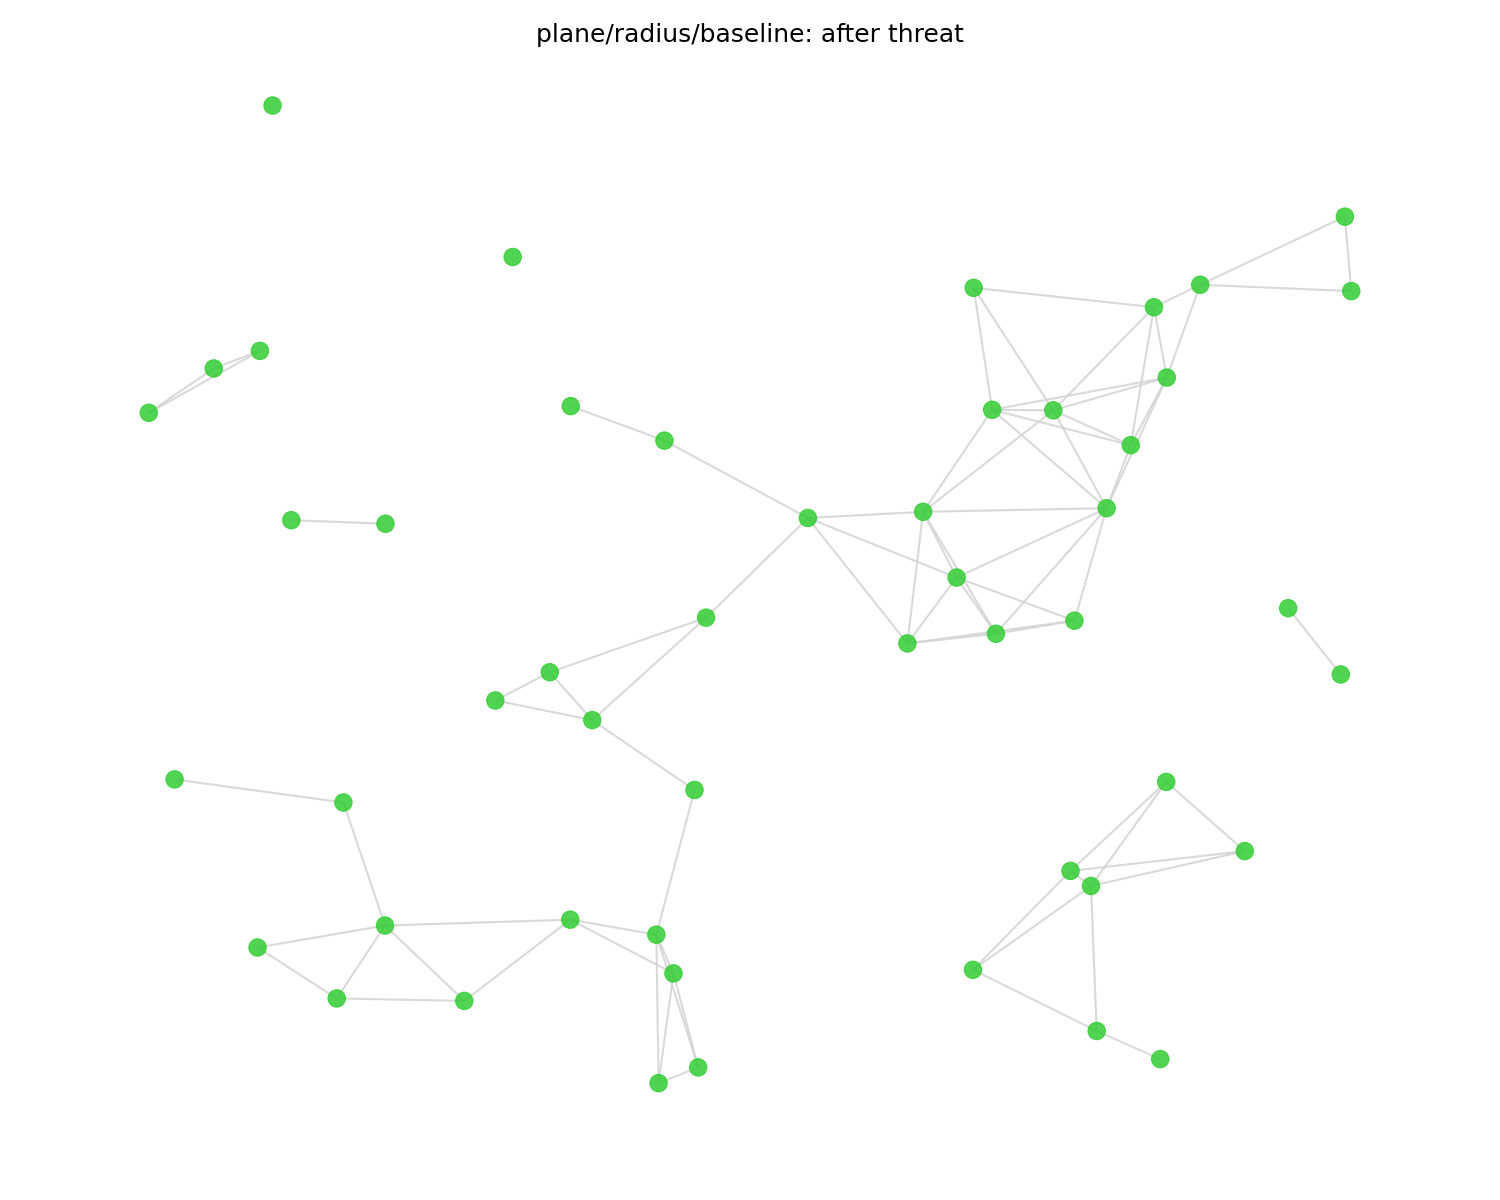

**Рис. rogue (plane/radius): после воздействия**

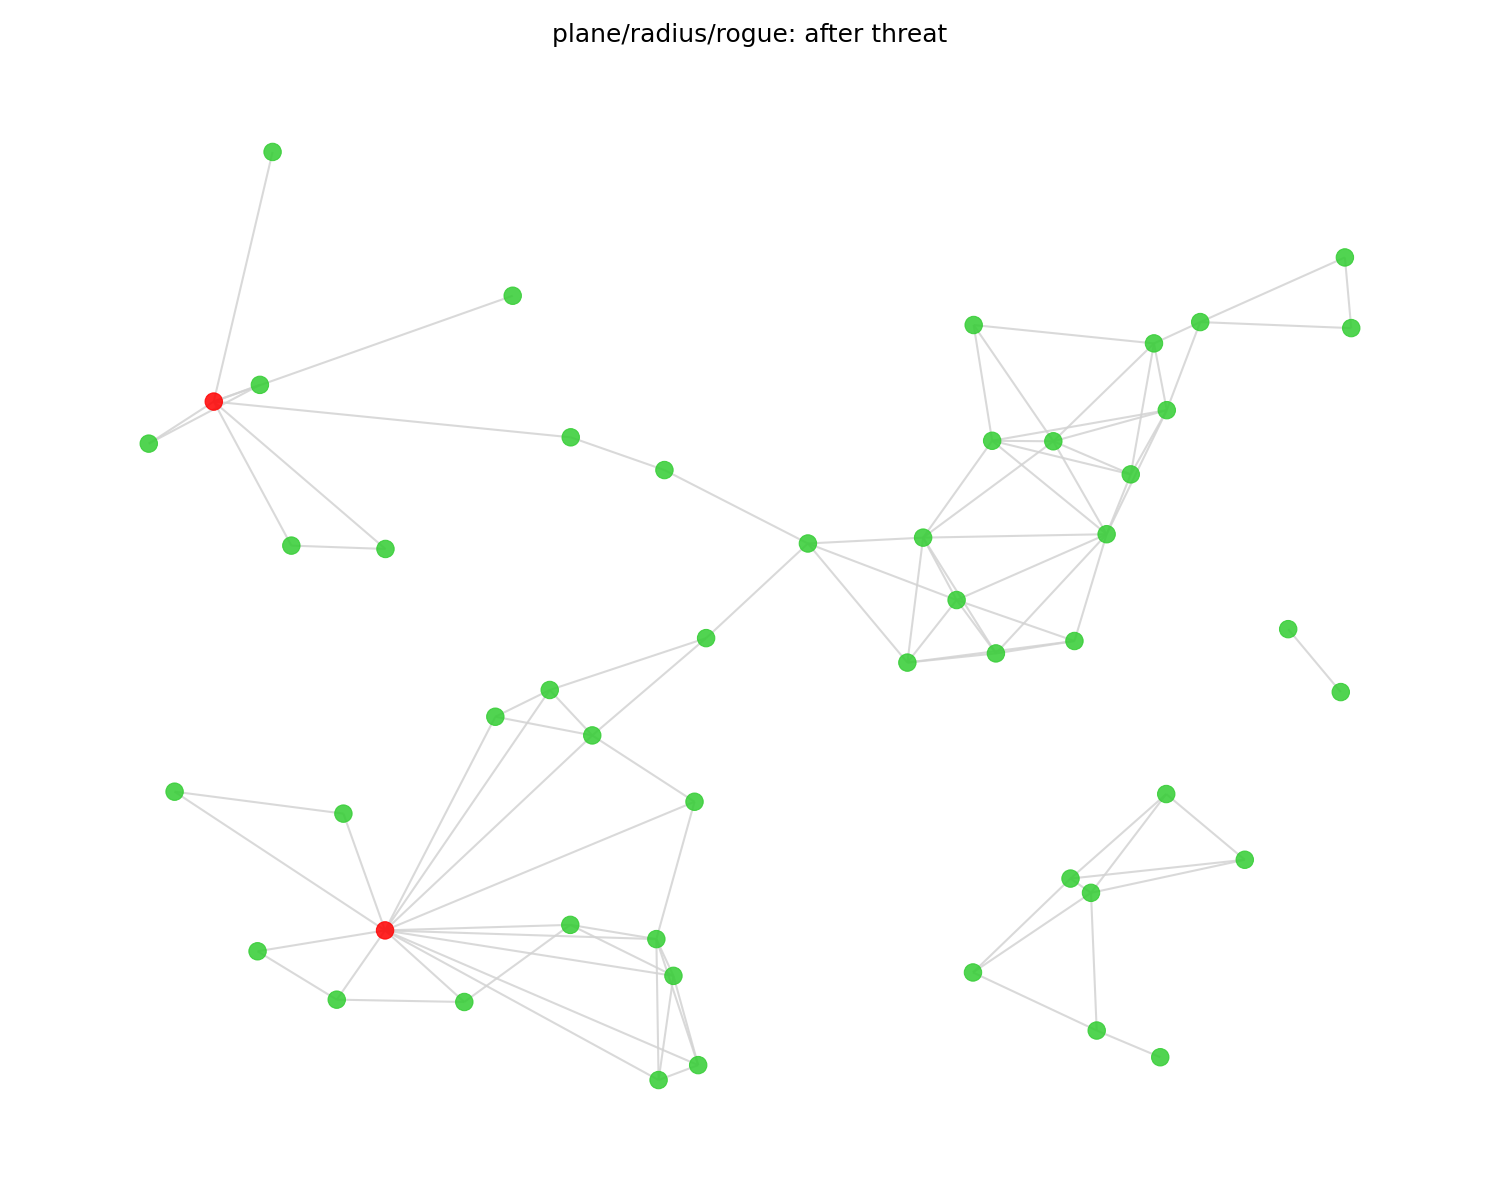

**Рис. flooding (plane/radius): после воздействия**

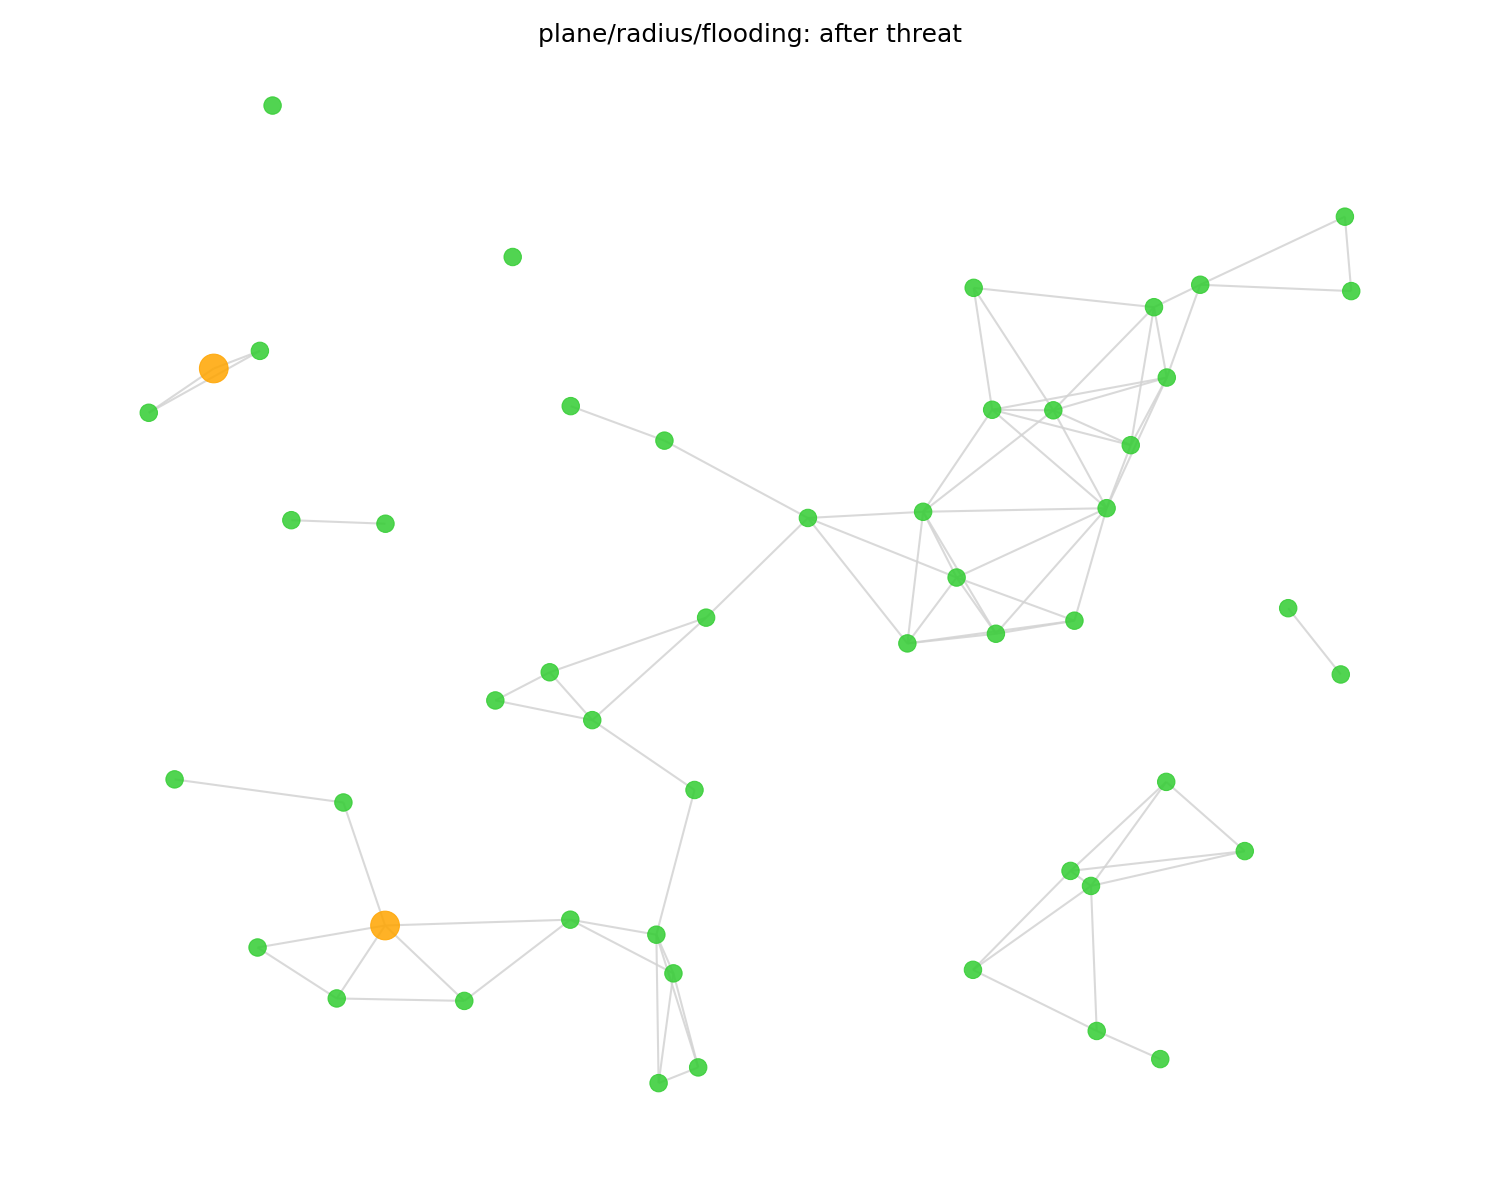

**Рис. isolation (plane/radius): после воздействия**

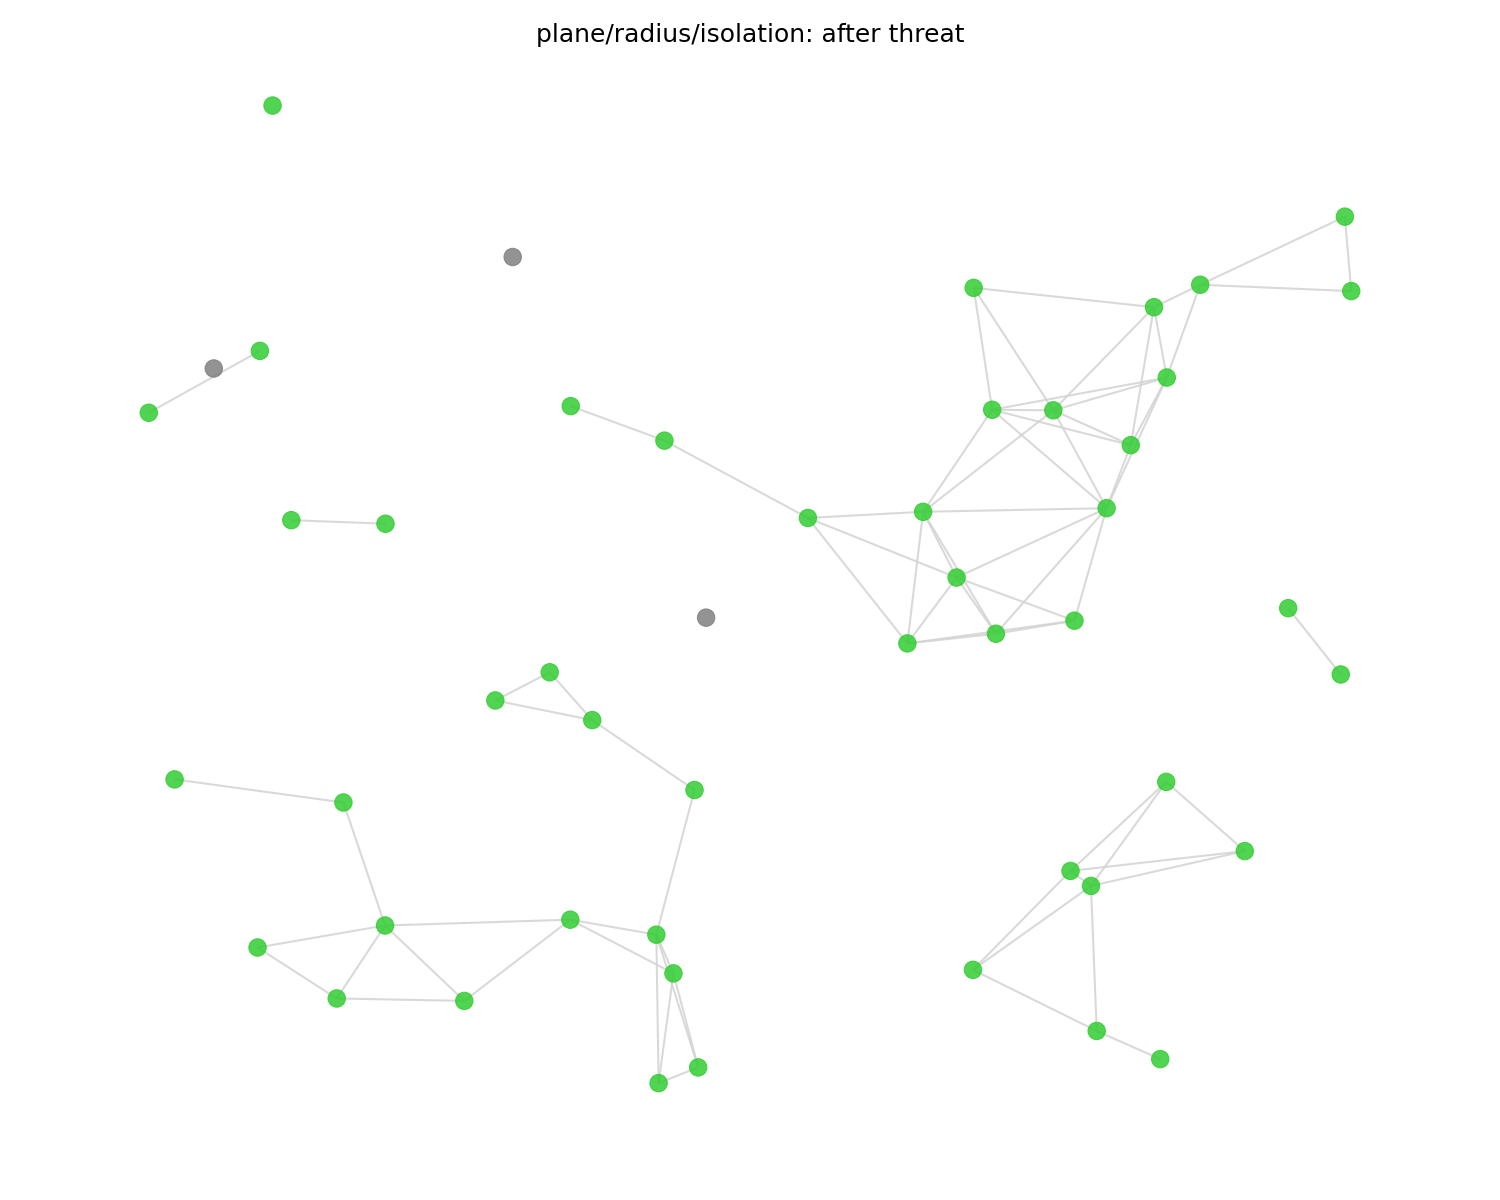

**Рис. spoofing (plane/radius): после воздействия**

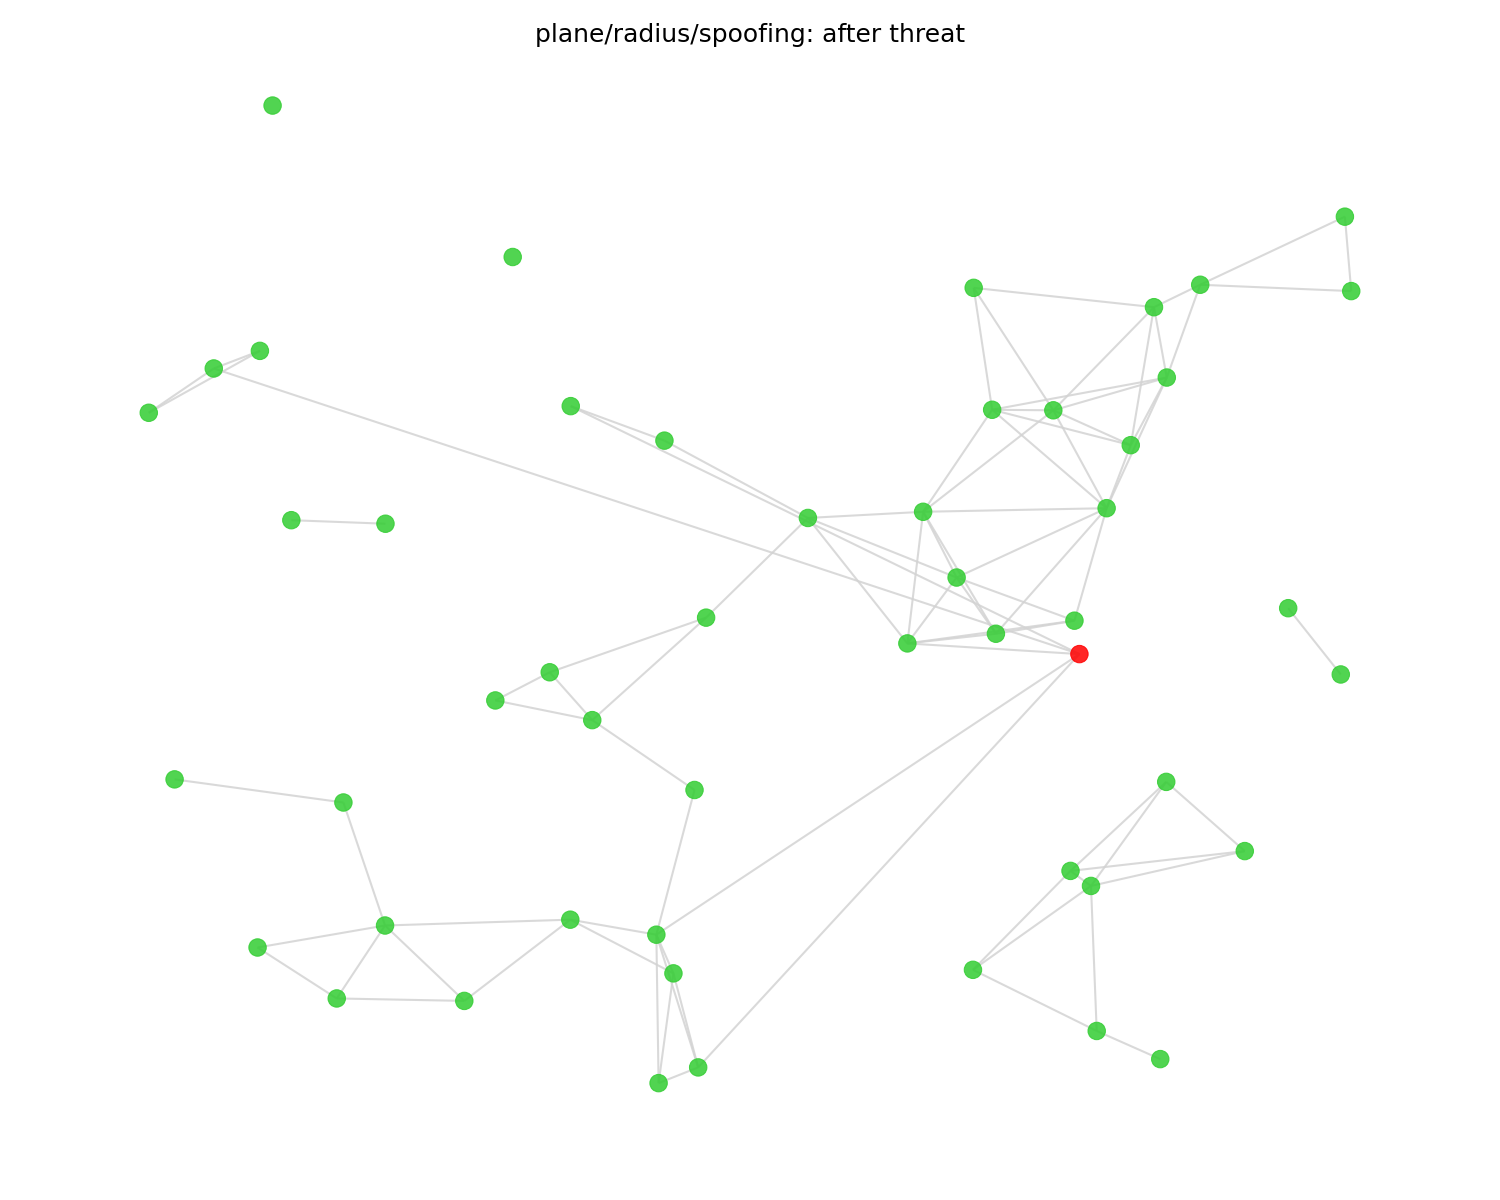

### PLANE / KNN

**Рис. baseline (plane/knn): после воздействия**

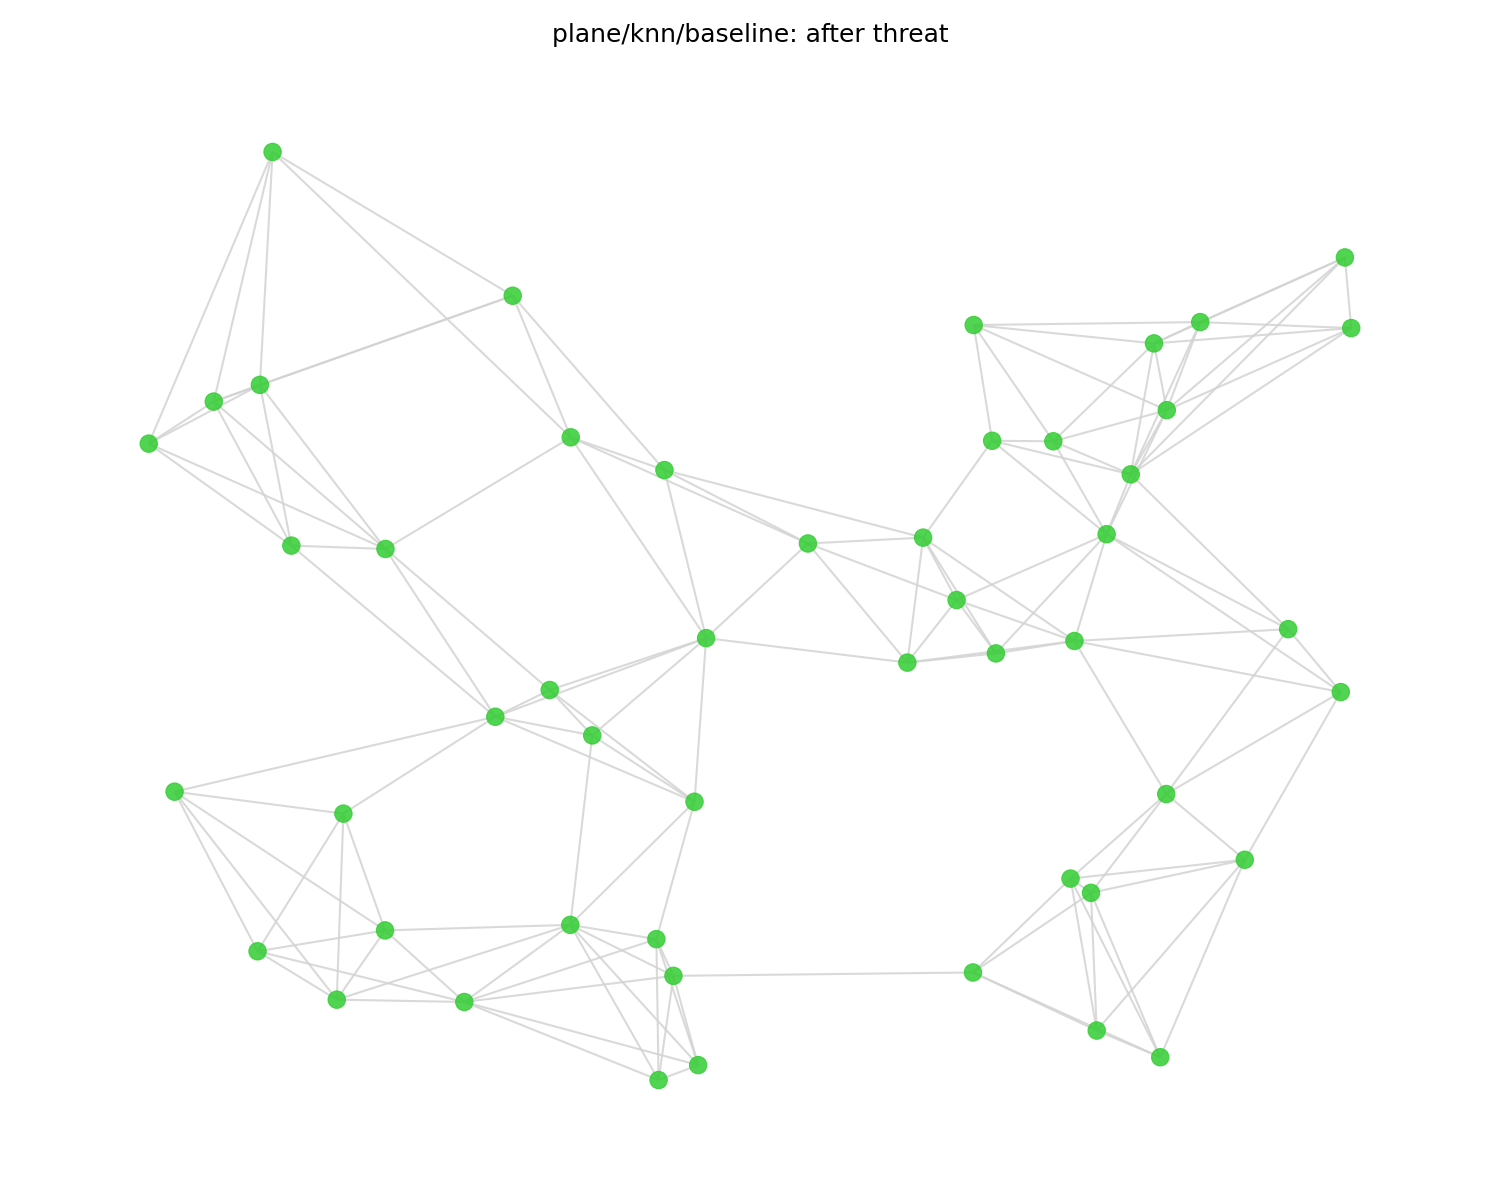

**Рис. rogue (plane/knn): после воздействия**

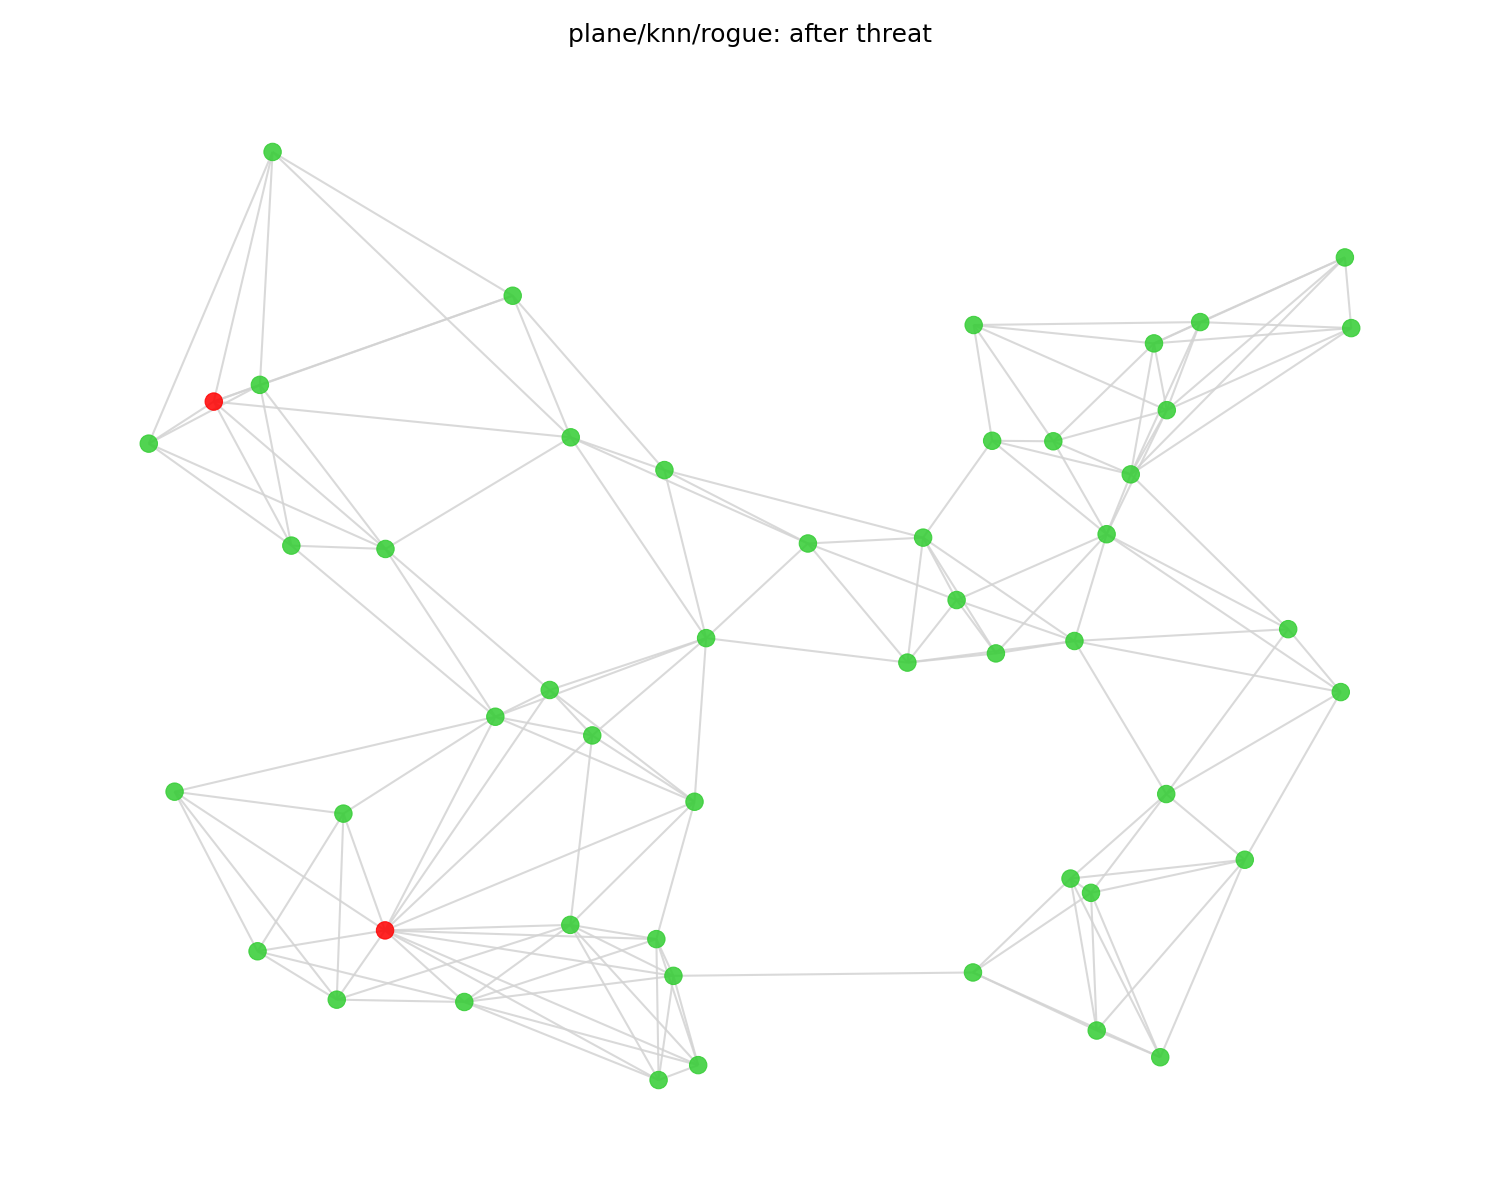

**Рис. flooding (plane/knn): после воздействия**

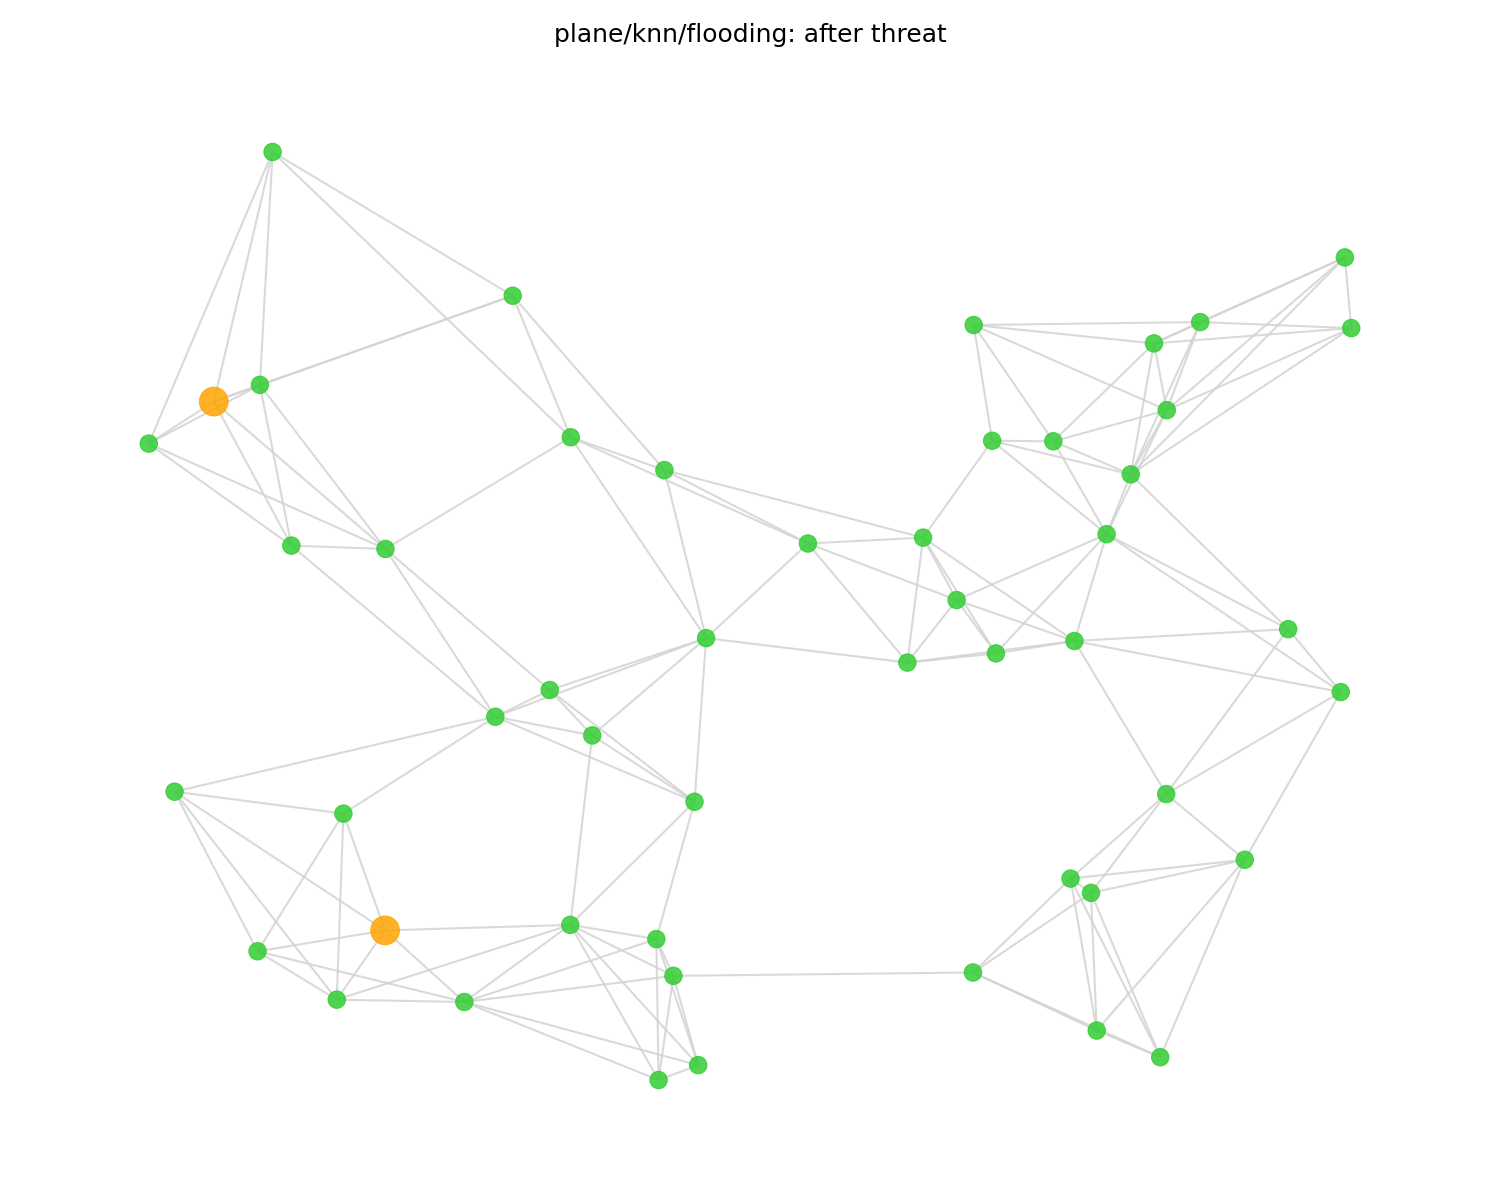

**Рис. isolation (plane/knn): после воздействия**

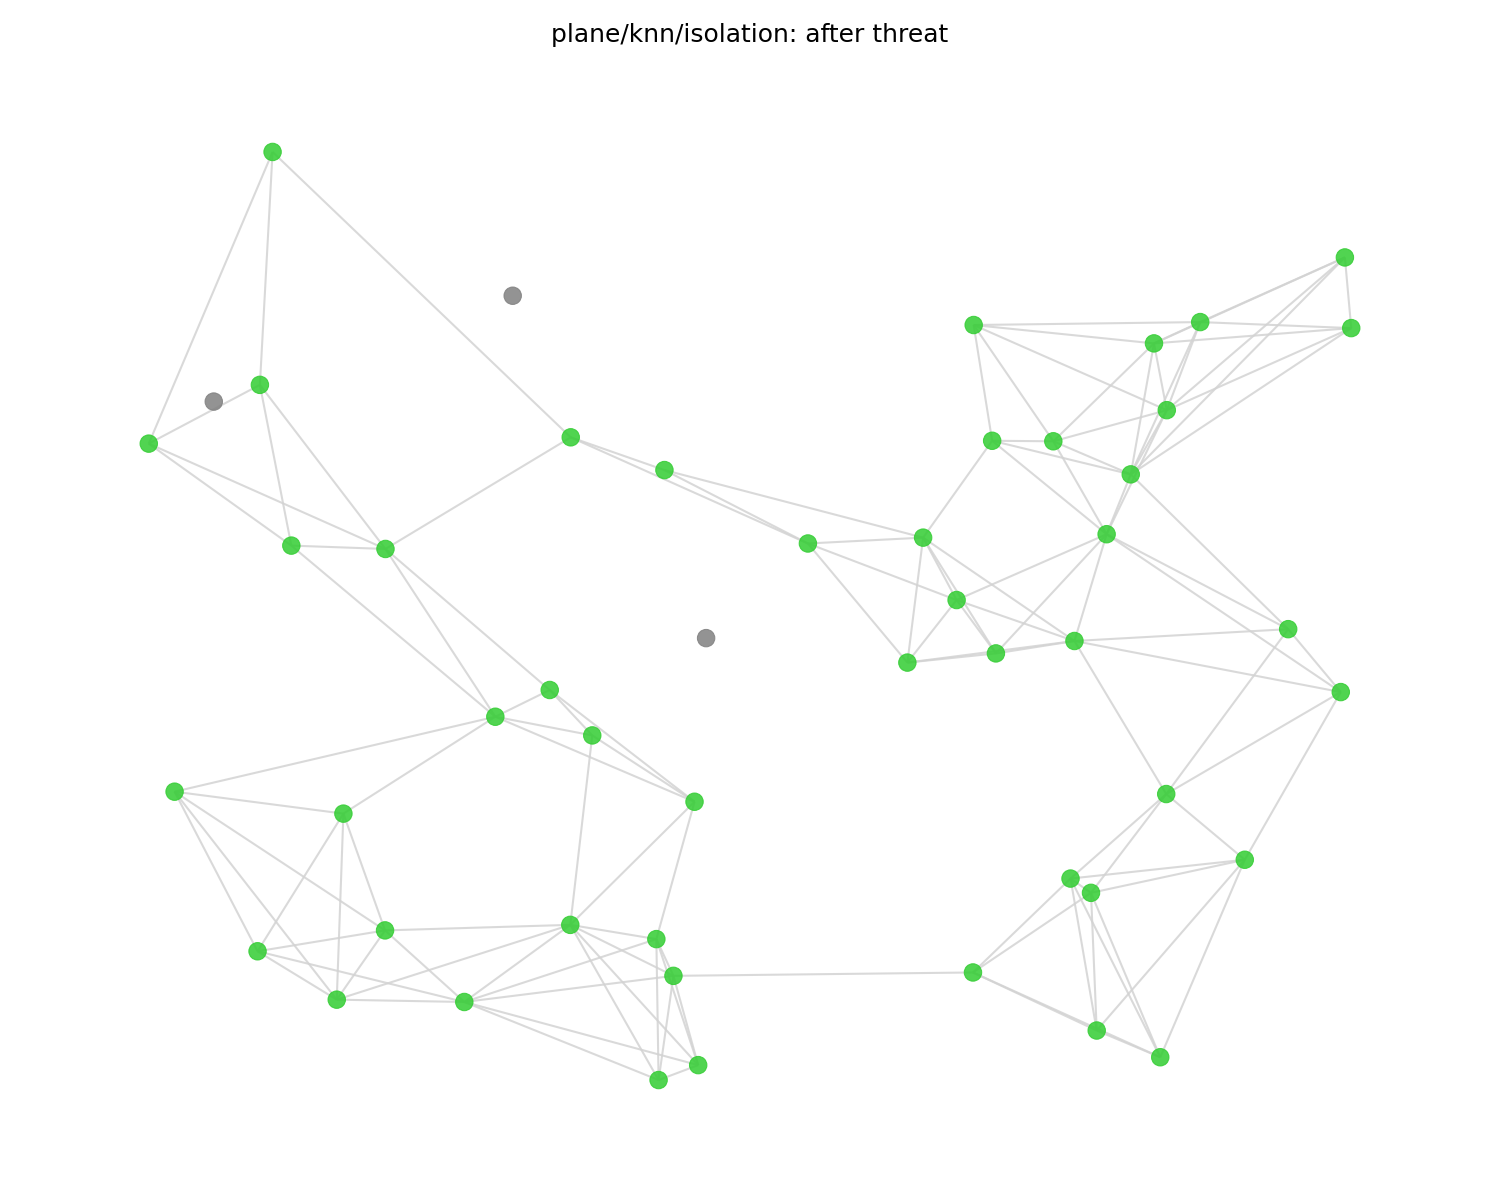

**Рис. spoofing (plane/knn): после воздействия**

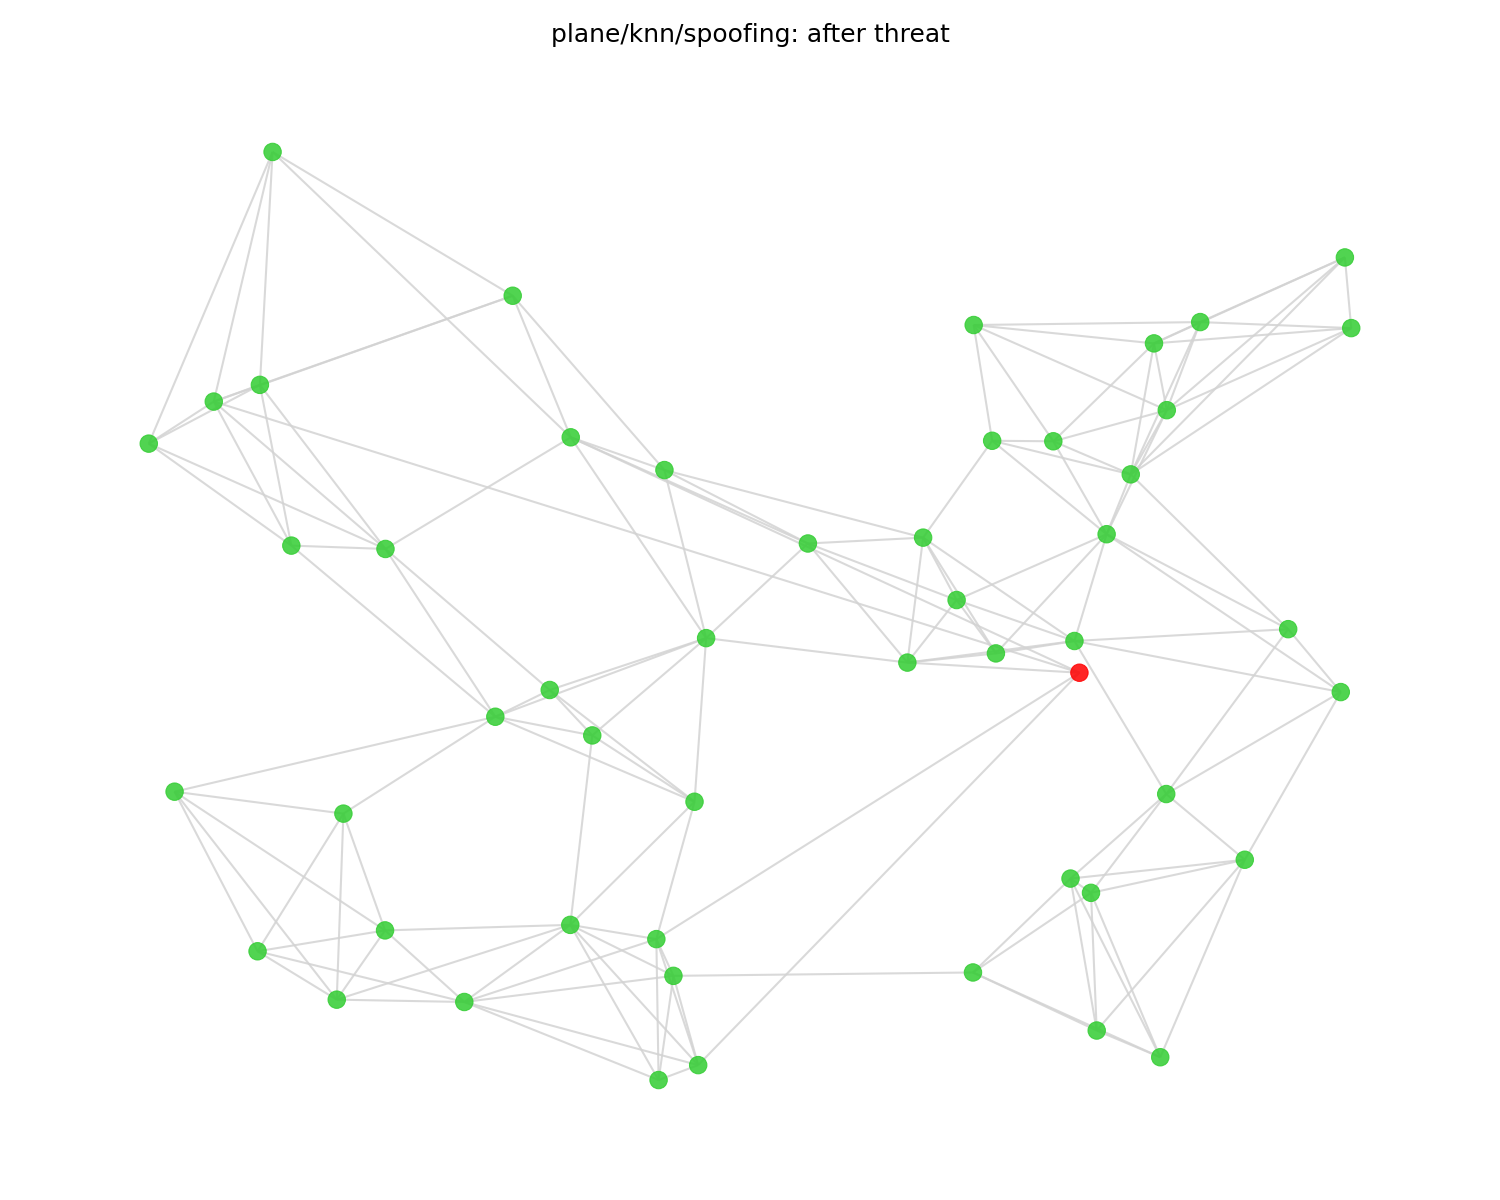

### GEO / RADIUS

**Рис. baseline (geo/radius): после воздействия**

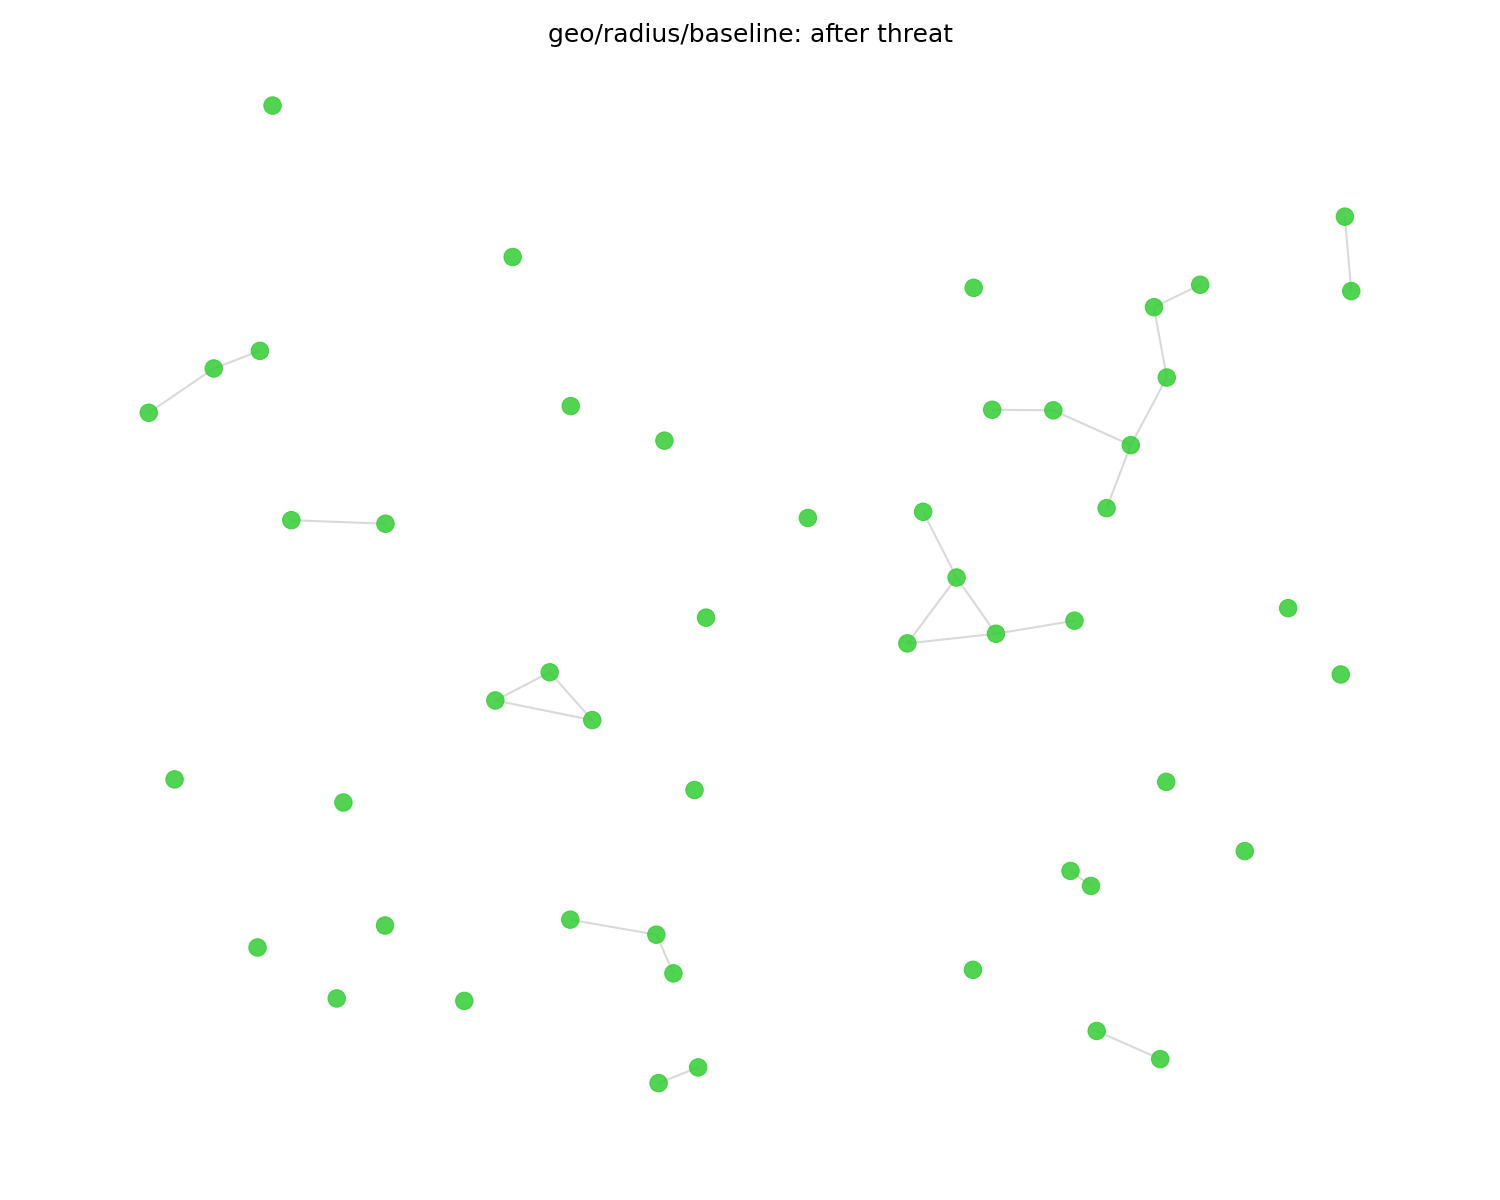

**Рис. rogue (geo/radius): после воздействия**

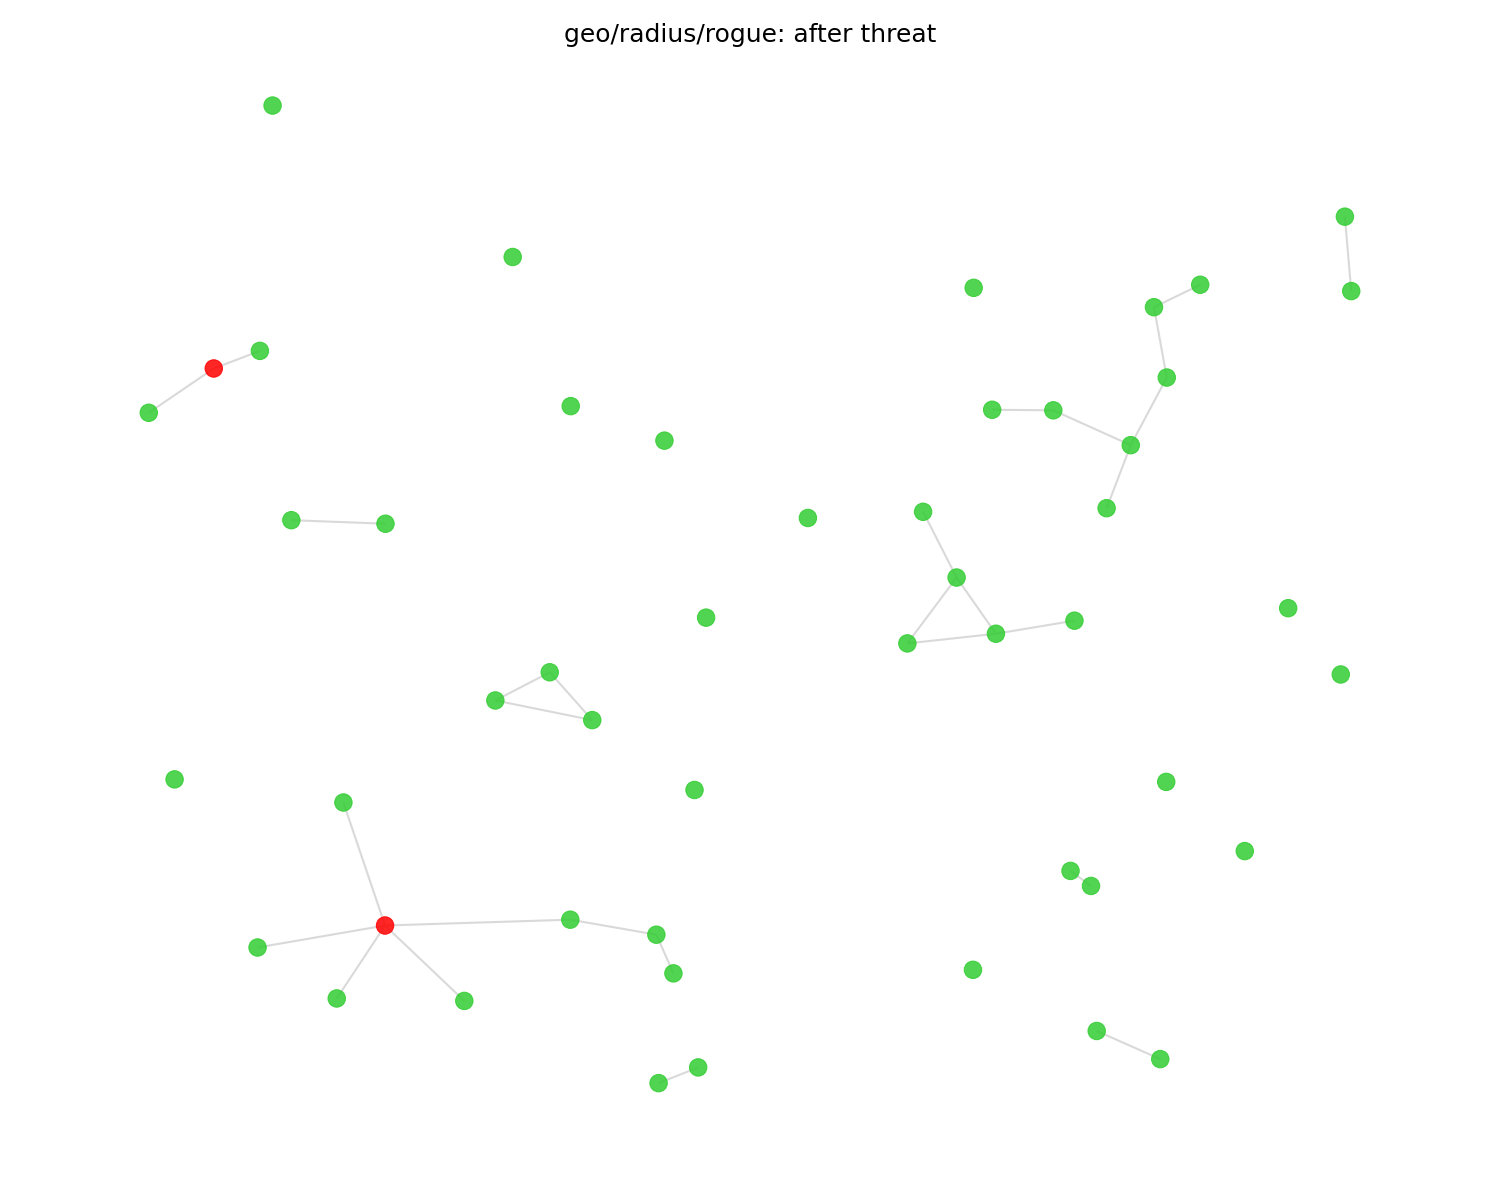

**Рис. flooding (geo/radius): после воздействия**

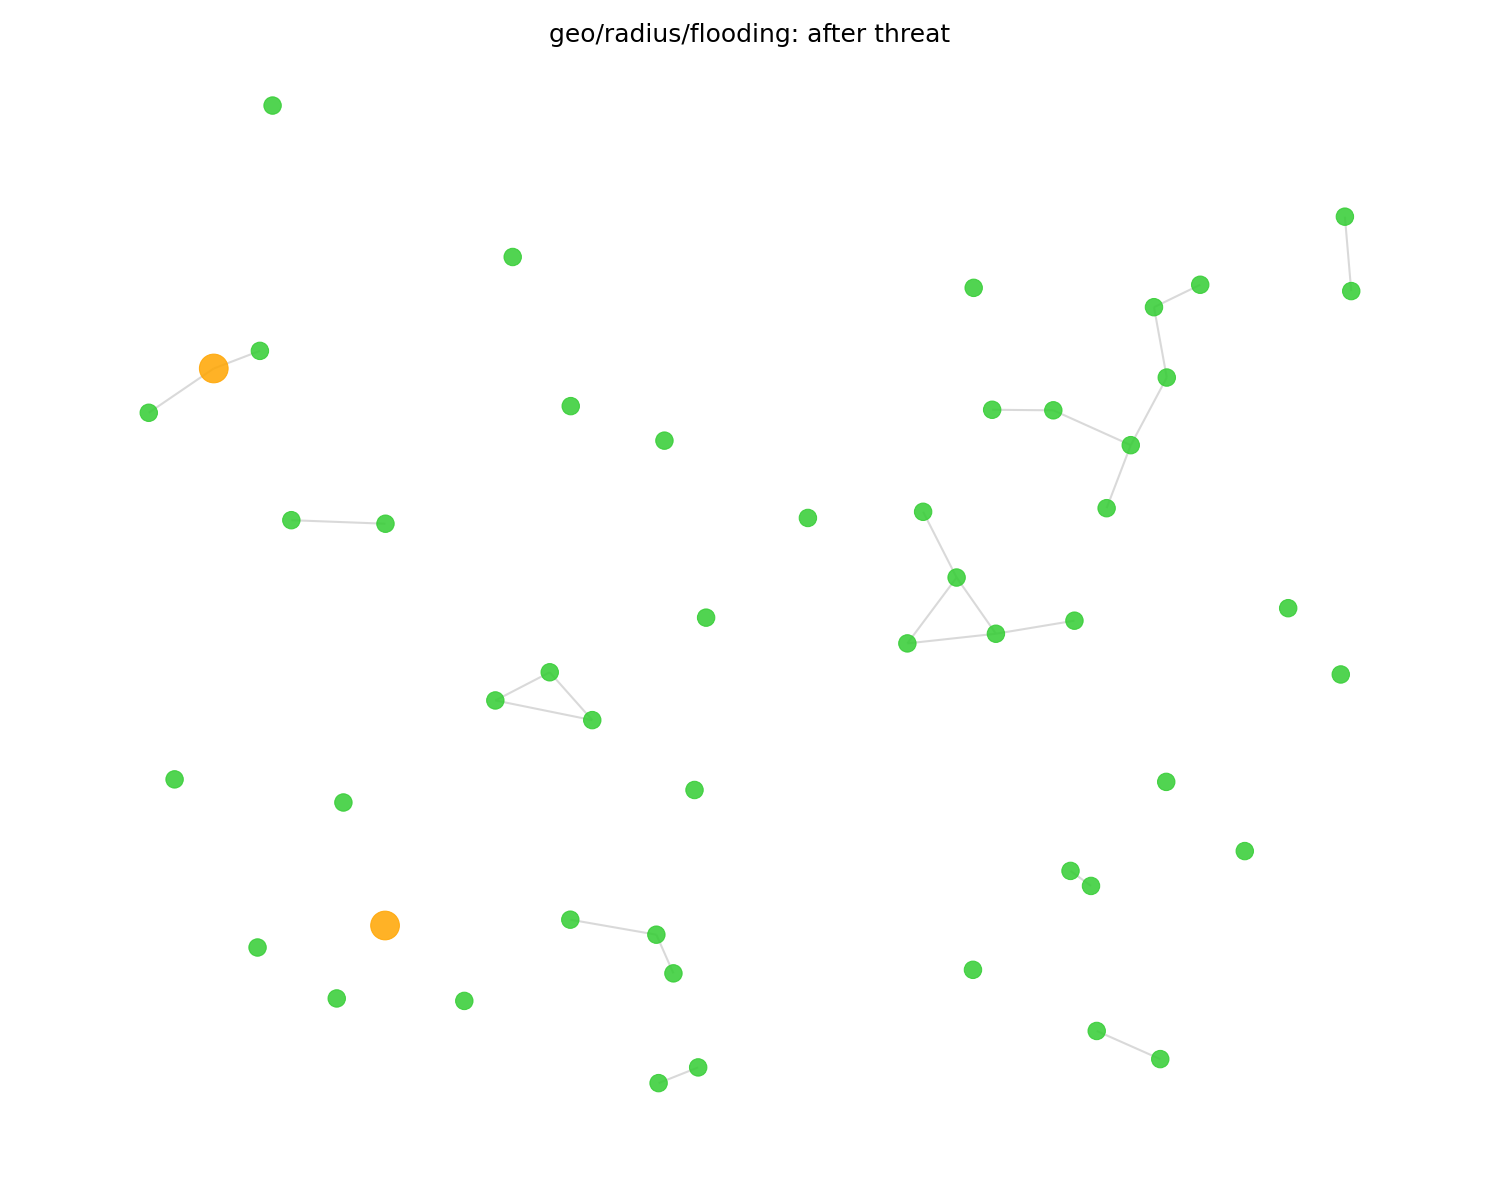

**Рис. isolation (geo/radius): после воздействия**

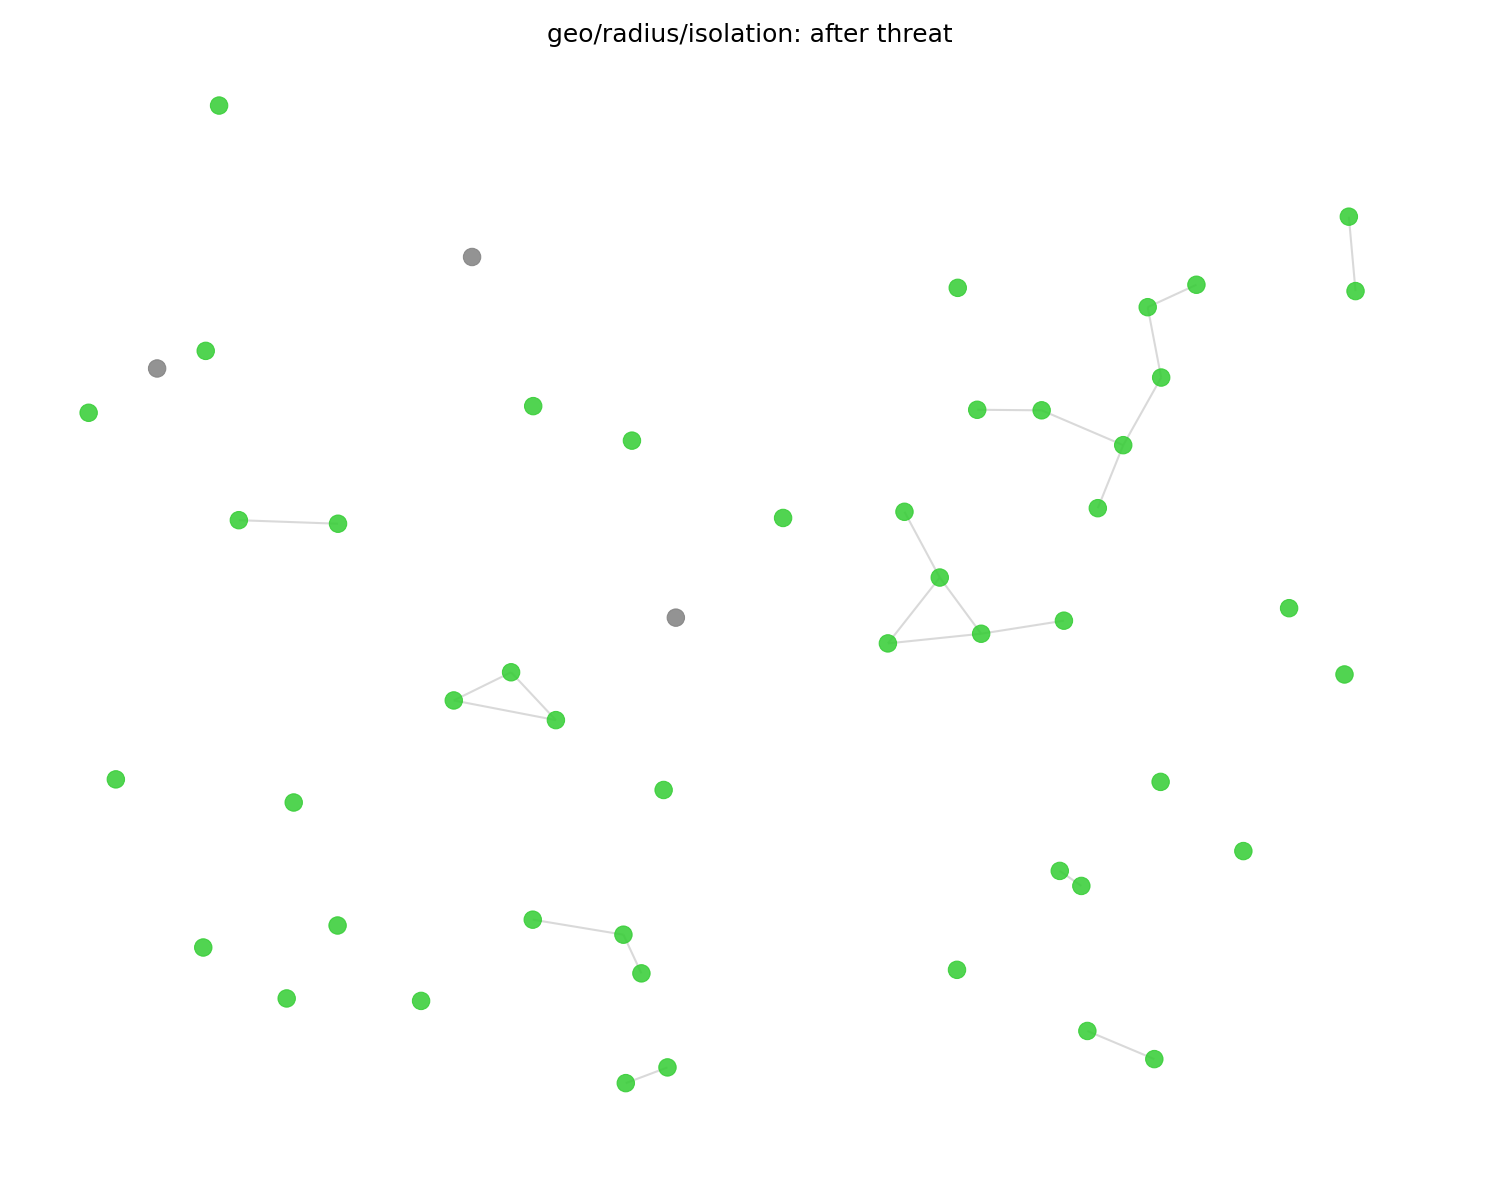

**Рис. spoofing (geo/radius): после воздействия**

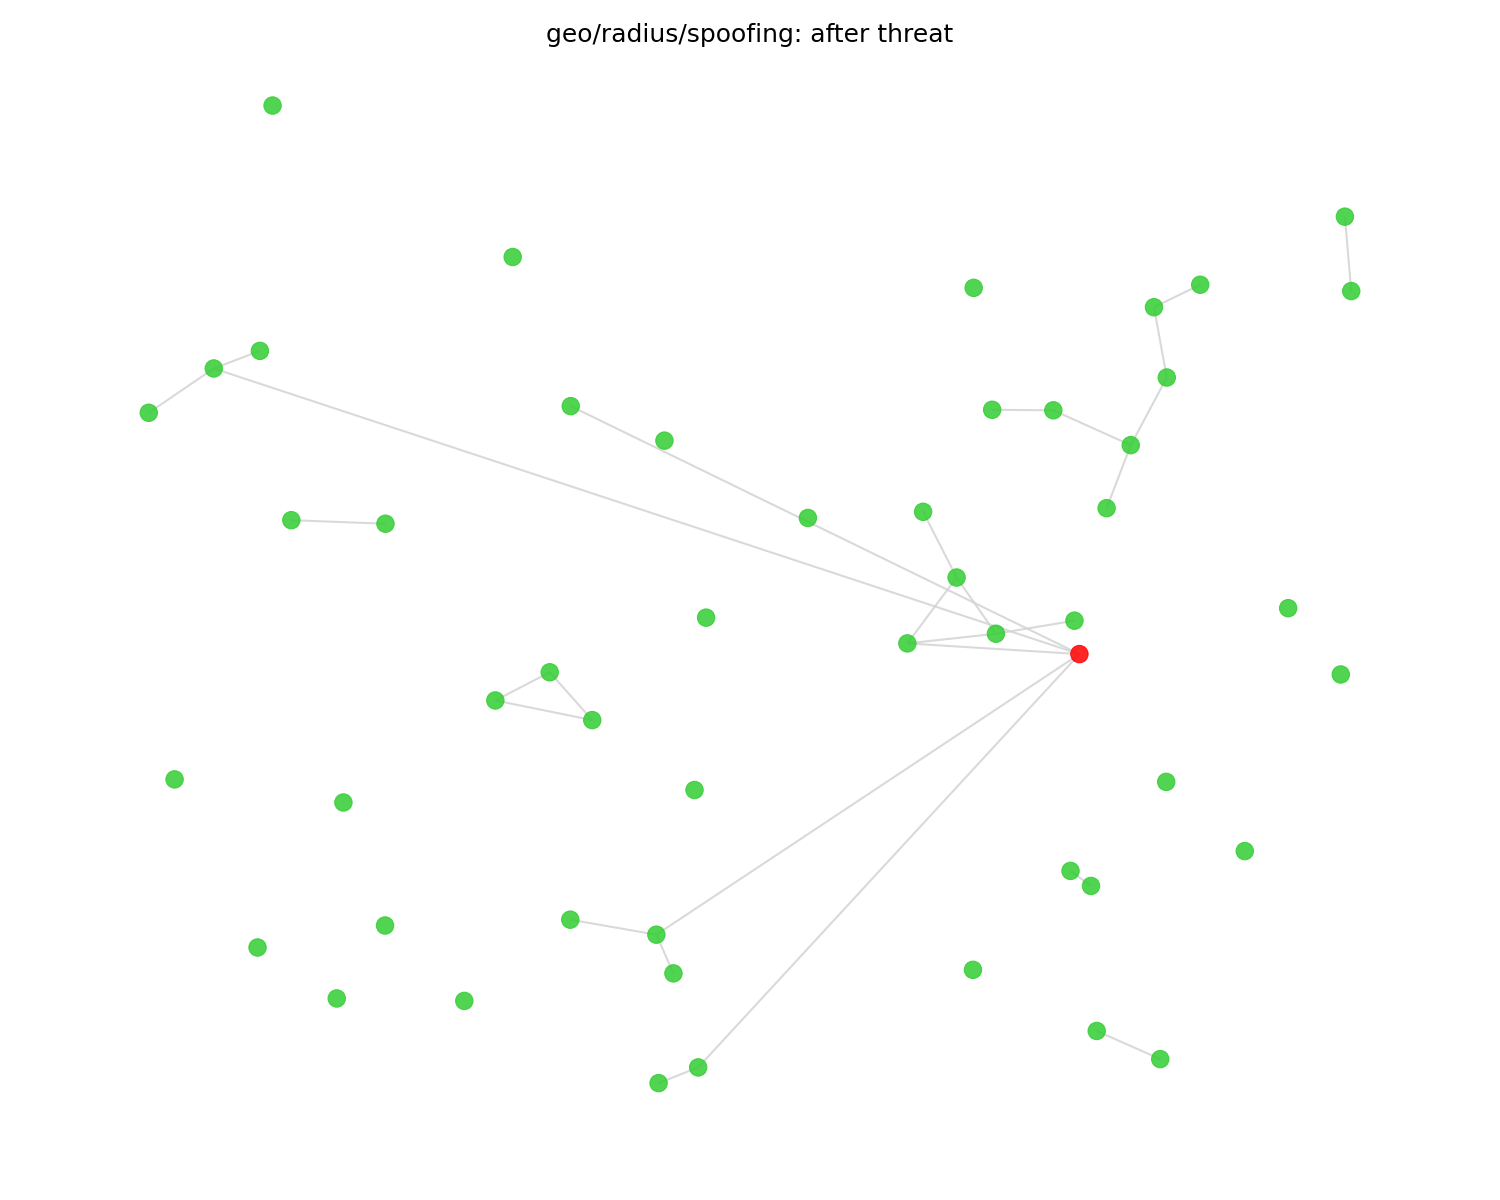

### GEO / KNN

**Рис. baseline (geo/knn): после воздействия**

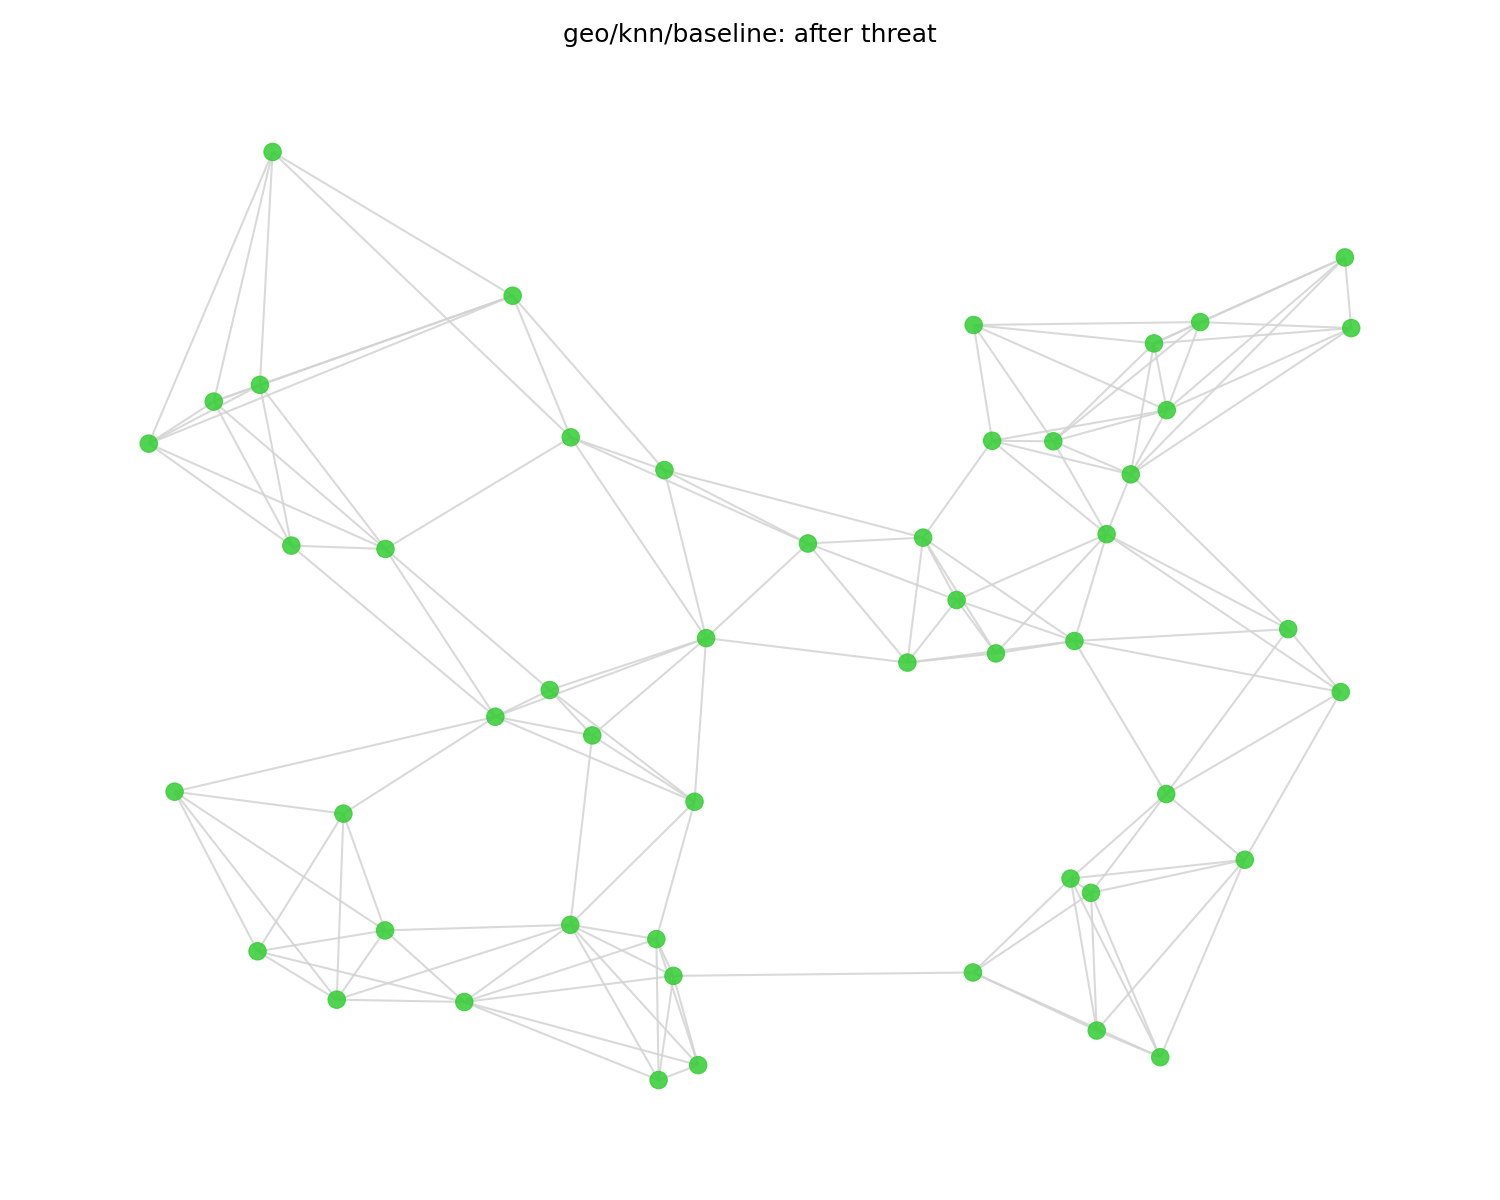

**Рис. rogue (geo/knn): после воздействия**

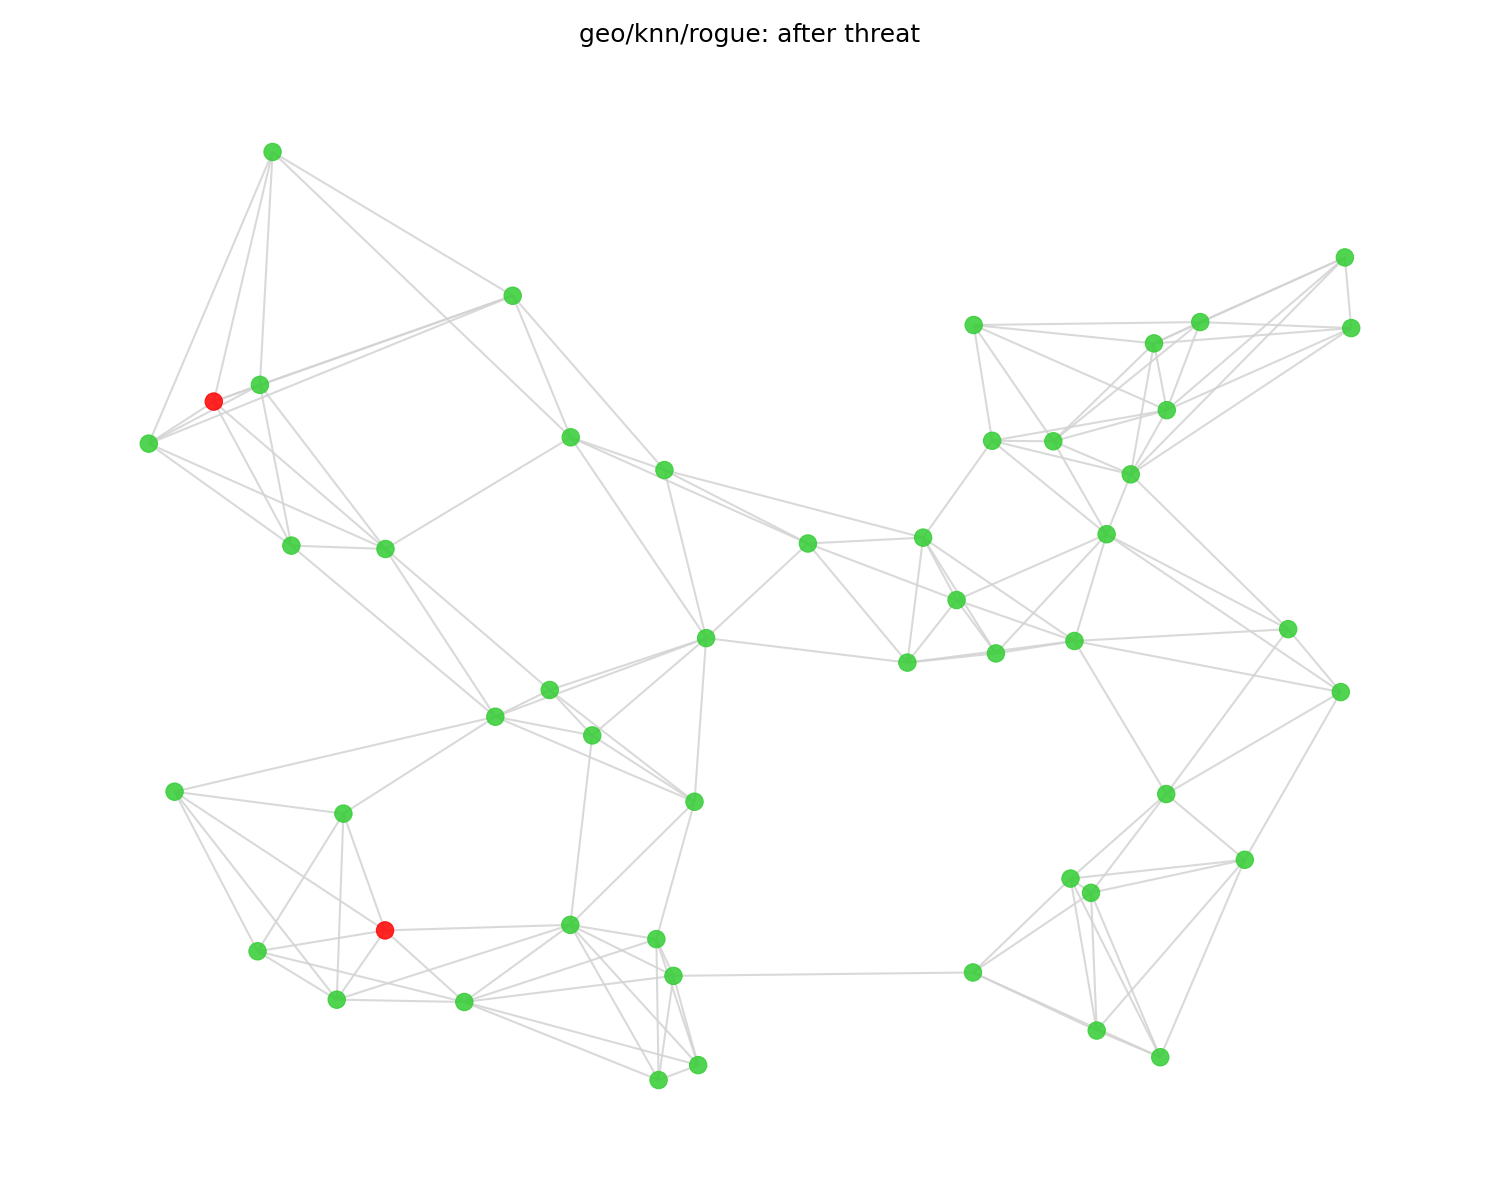

**Рис. flooding (geo/knn): после воздействия**

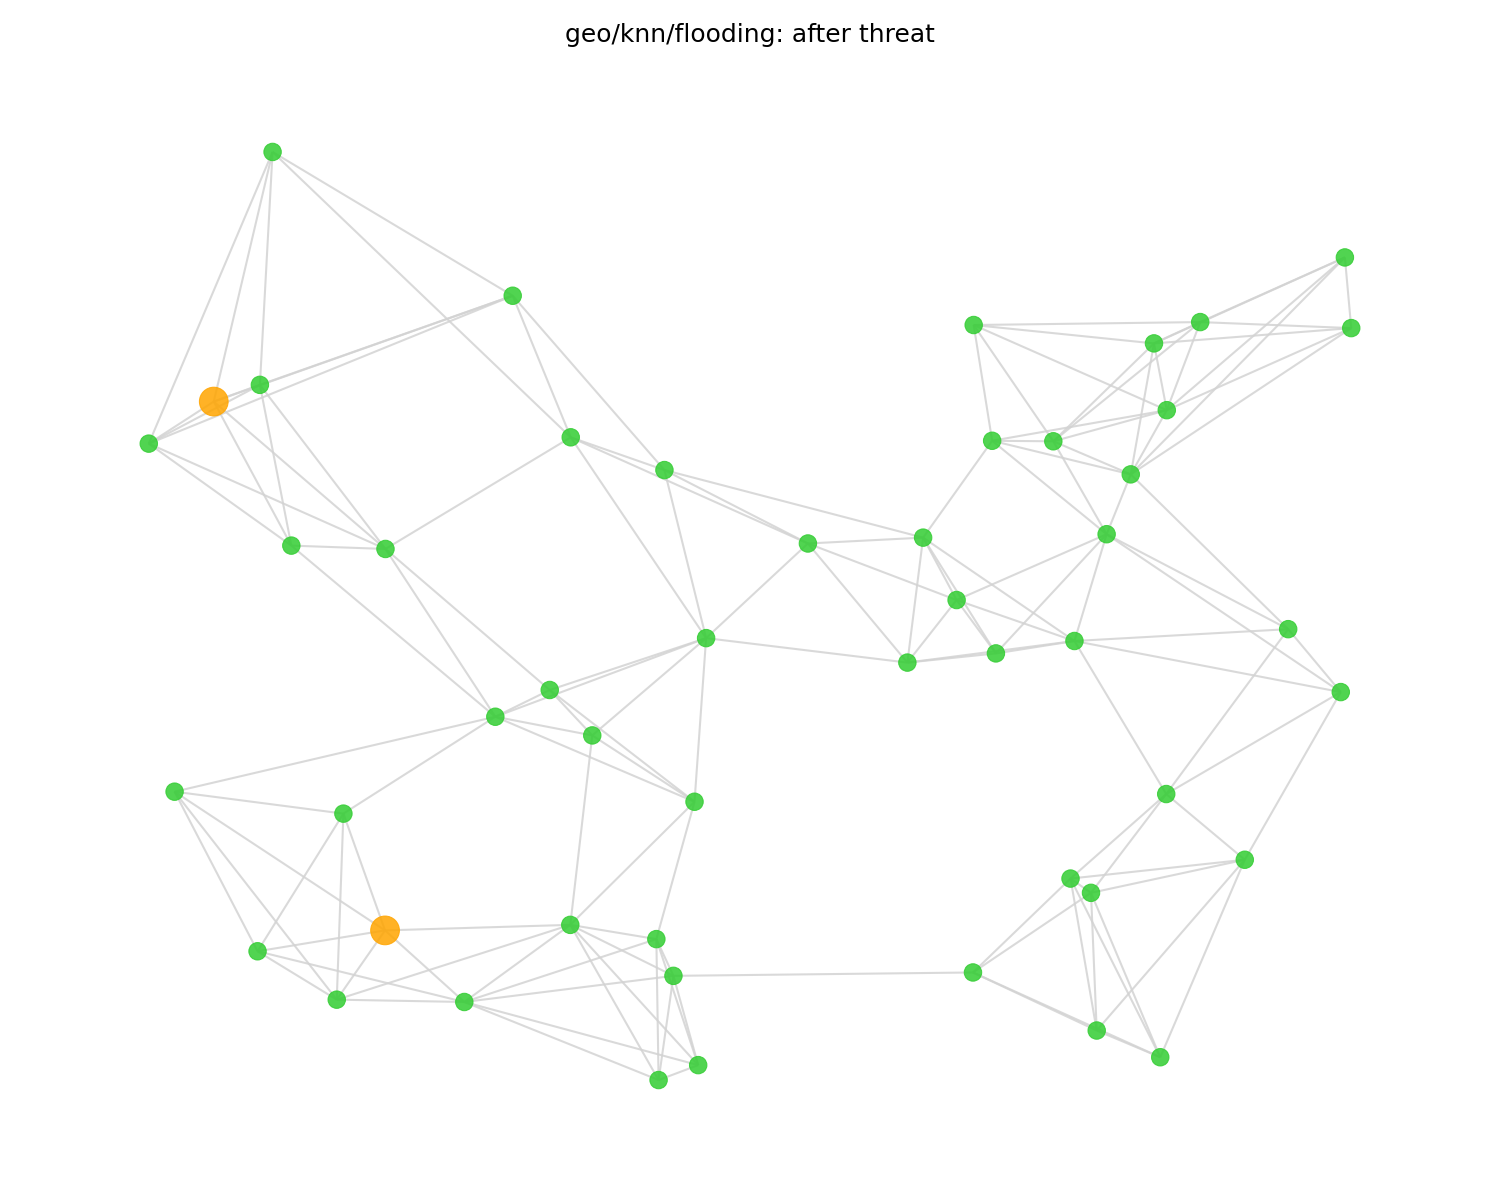

**Рис. isolation (geo/knn): после воздействия**

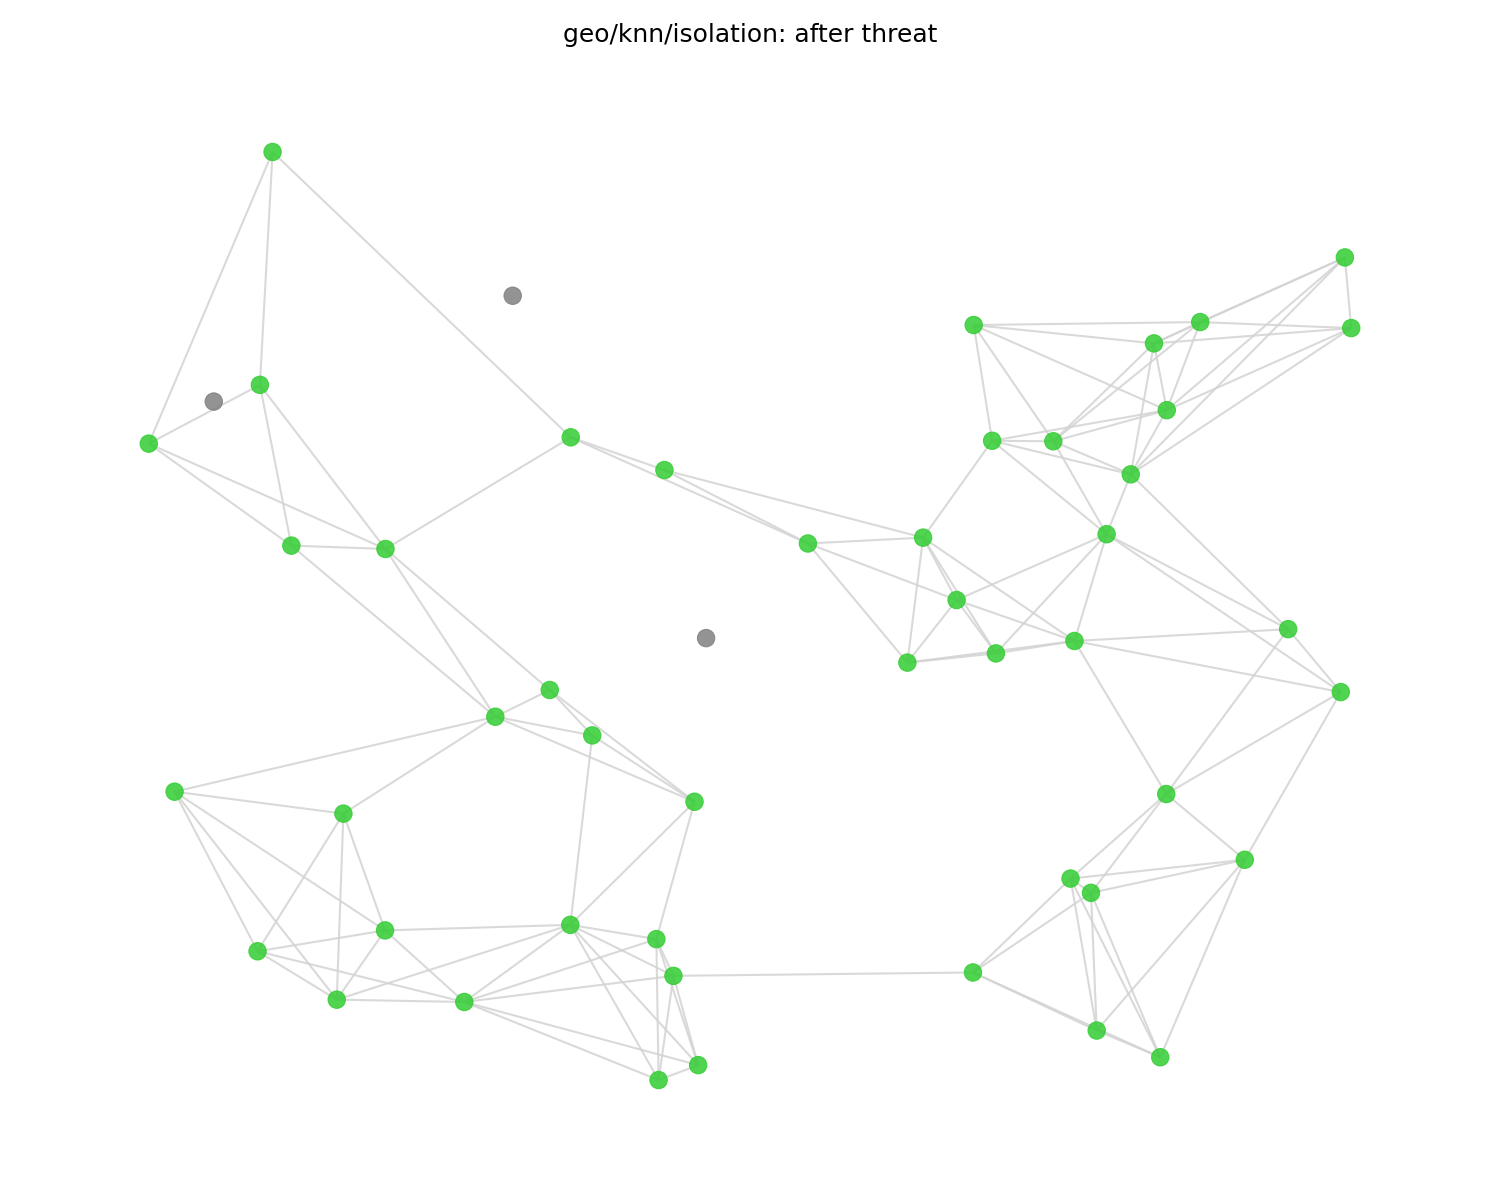

**Рис. spoofing (geo/knn): после воздействия**

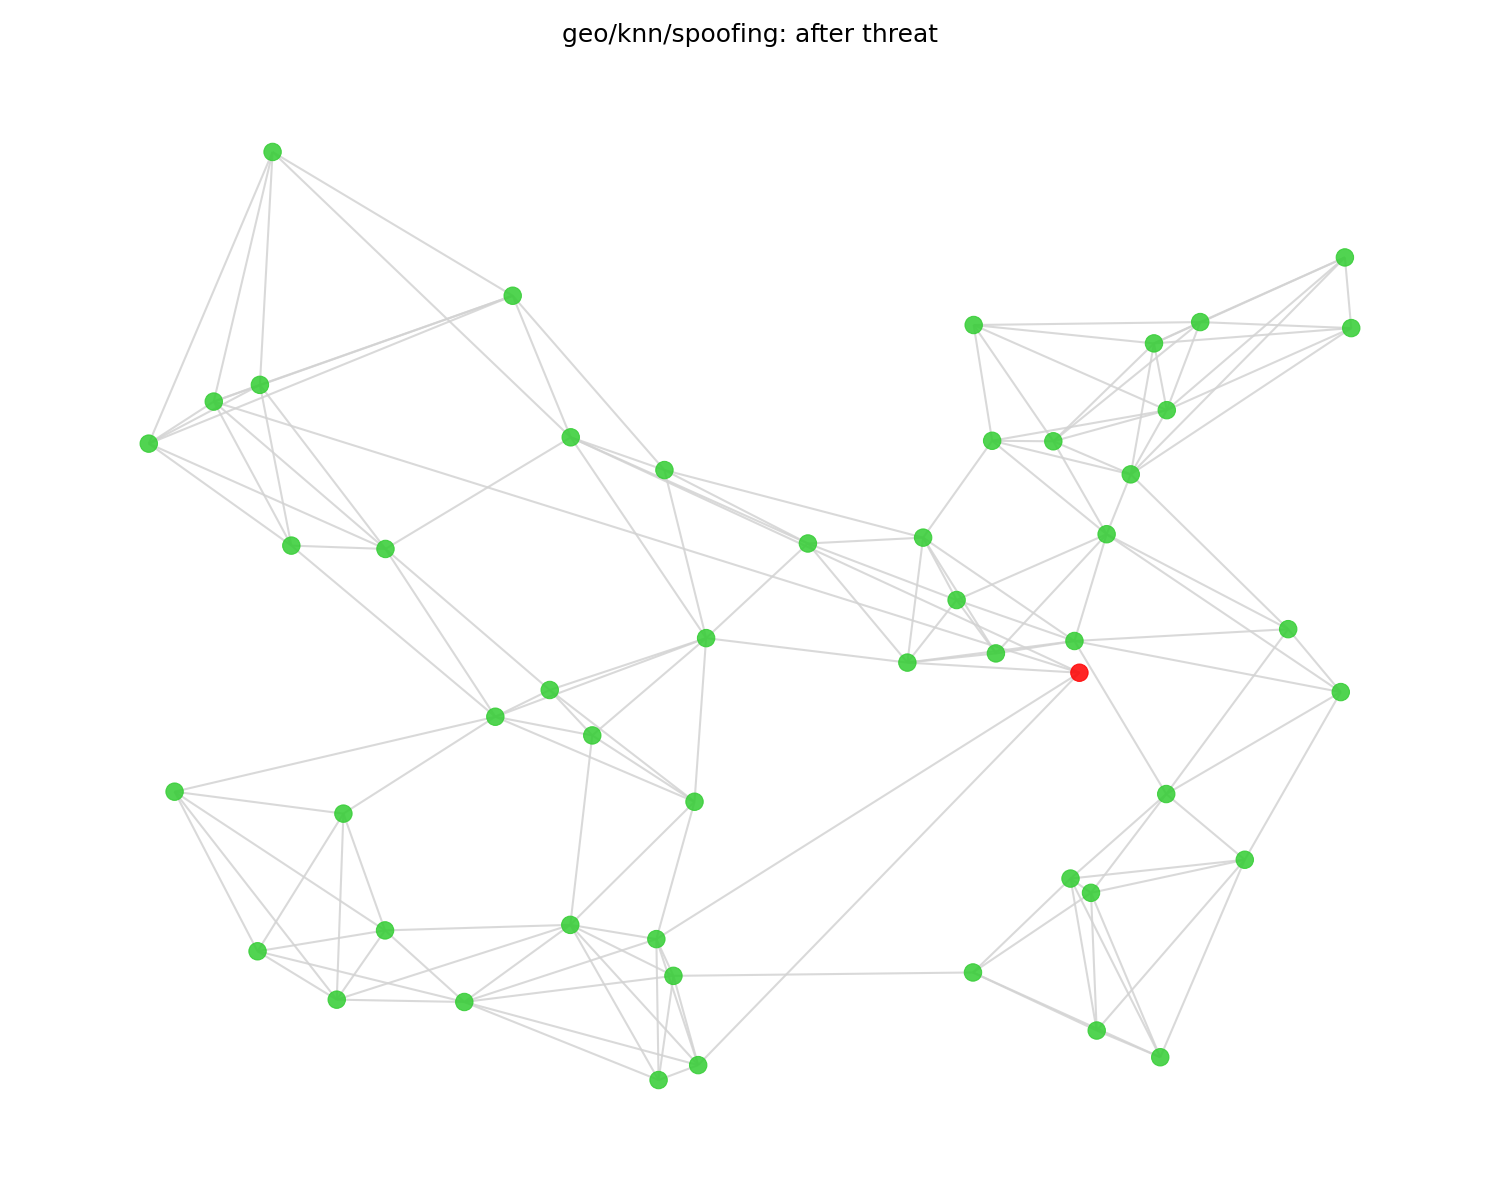

In [12]:
for coord in AVAILABLE_COORDS:
    for graph in GRAPH_TYPES:
        if (coord, graph) not in summaries:
            continue

        display(Markdown(f"### {coord.upper()} / {graph.upper()}"))
        for scenario in SCENARIOS:
            p = figure_path(coord, graph, scenario)
            if p.exists():
                display(Markdown(f"**Рис. {scenario} ({coord}/{graph}): после воздействия**"))
                display(Image(str(p), width=650))
            else:
                print(f"[SKIP] Нет рисунка: {p.relative_to(project_root)}")


## 12. Интерактивные карты

HTML-карты не встраиваются напрямую в GitHub-просмотр ноутбука, но их можно открыть локально в браузере.


In [13]:
map_rows = []
for coord in AVAILABLE_COORDS:
    for graph in GRAPH_TYPES:
        for scenario in SCENARIOS:
            p = map_path(coord, graph, scenario)
            if p.exists():
                map_rows.append({
                    "coord": coord,
                    "graph_type": graph,
                    "scenario": scenario,
                    "map_file": str(p.relative_to(project_root)),
                })

maps_df = pd.DataFrame(map_rows)
if maps_df.empty:
    display(Markdown("HTML-карты не найдены."))
else:
    display(maps_df)


,coord,graph_type,scenario,map_file
0,plane,radius,baseline,outputs/maps/radius/baseline_map.html
1,plane,radius,rogue,outputs/maps/radius/rogue_map.html
2,plane,radius,flooding,outputs/maps/radius/flooding_map.html
3,plane,radius,isolation,outputs/maps/radius/isolation_map.html
4,plane,radius,spoofing,outputs/maps/radius/spoofing_map.html
5,plane,knn,baseline,outputs/maps/knn/baseline_map.html
6,plane,knn,rogue,outputs/maps/knn/rogue_map.html
7,plane,knn,flooding,outputs/maps/knn/flooding_map.html
8,plane,knn,isolation,outputs/maps/knn/isolation_map.html
9,plane,knn,spoofing,outputs/maps/knn/spoofing_map.html


## 13. Автоматически сформированный аналитический вывод

Этот блок делает аккуратную первичную сборку выводов.  
Текст можно использовать как черновик для раздела результатов, но перед вставкой в ВКР его нужно вручную вычитать.


In [14]:
def get_summary_df(coord: str, graph: str) -> pd.DataFrame | None:
    return summaries.get((coord, graph))

def auto_conclusion_for_coord(coord: str) -> str:
    parts = []

    r = get_summary_df(coord, "radius")
    k = get_summary_df(coord, "knn")

    if r is not None and k is not None:
        r_comp = metric_value(r, "baseline", "num_components")
        k_comp = metric_value(k, "baseline", "num_components")
        r_edges = metric_value(r, "baseline", "edges")
        k_edges = metric_value(k, "baseline", "edges")
        parts.append(
            f"В режиме `{coord}` baseline-топология различается по двум моделям графа: "
            f"`radius` имеет {r_edges:.0f} рёбер и {r_comp:.0f} компонент(ы), "
            f"тогда как `k-NN` имеет {k_edges:.0f} рёбер и {k_comp:.0f} компонент(ы). "
            "Это подтверждает, что radius-граф отражает более физически ограниченную сетевую доступность, "
            "а k-NN-граф задаёт более связную сравнительную топологию."
        )

    if not analysis_df.empty:
        sub = analysis_df[analysis_df["coord"] == coord]
        for scenario in ["rogue", "flooding", "isolation", "spoofing"]:
            s = sub[sub["scenario"] == scenario]
            if s.empty:
                continue
            strongest = s.sort_values("risk_score", ascending=False).iloc[0]
            parts.append(
                f"Сценарий `{scenario}` наиболее выражен в модели `{strongest['graph_type']}` "
                f"со статусом {strongest['traffic']} и оценкой {strongest['risk_score']:.1f}. "
                f"Ключевые признаки: {strongest['key_signals']}."
            )

    if not response_comparison_df.empty:
        rc = response_comparison_df[response_comparison_df["coord"] == coord]
        if not rc.empty:
            sens = rc["more_sensitive"].value_counts().to_dict()
            parts.append(
                "Сравнение чувствительности показывает распределение по сценариям: "
                + ", ".join(f"{k}: {v}" for k, v in sens.items())
                + ". Это помогает обосновать использование двух моделей графа одновременно."
            )

    return "\n\n".join(parts)

for coord in AVAILABLE_COORDS:
    display(Markdown(f"### Вывод для режима `{coord}`"))
    display(Markdown(auto_conclusion_for_coord(coord)))


### Вывод для режима `plane`

В режиме `plane` baseline-топология различается по двум моделям графа: `radius` имеет 82 рёбер и 7 компонент(ы), тогда как `k-NN` имеет 150 рёбер и 1 компонент(ы). Это подтверждает, что radius-граф отражает более физически ограниченную сетевую доступность, а k-NN-граф задаёт более связную сравнительную топологию.

Сценарий `rogue` наиболее выражен в модели `radius` со статусом КРАСНЫЙ и оценкой 72.3. Ключевые признаки: компоненты -4; рёбра +17.1%; degree centrality +75.0%; betweenness +71.9%.

Сценарий `flooding` наиболее выражен в модели `radius` со статусом ЖЁЛТЫЙ и оценкой 59.0. Ключевые признаки: аномалии нагрузки: 2.

Сценарий `isolation` наиболее выражен в модели `radius` со статусом КРАСНЫЙ и оценкой 68.9. Ключевые признаки: компоненты +3; LCC 47.1%↓; изолированные узлы +2; рёбра -6.1%.

Сценарий `spoofing` наиболее выражен в модели `radius` со статусом ЖЁЛТЫЙ и оценкой 25.9. Ключевые признаки: компоненты -1; рёбра +6.1%; узлы +1.

Сравнение чувствительности показывает распределение по сценариям: radius: 2, сходно: 2. Это помогает обосновать использование двух моделей графа одновременно.

### Вывод для режима `geo`

В режиме `geo` baseline-топология различается по двум моделям графа: `radius` имеет 23 рёбер и 29 компонент(ы), тогда как `k-NN` имеет 151 рёбер и 1 компонент(ы). Это подтверждает, что radius-граф отражает более физически ограниченную сетевую доступность, а k-NN-граф задаёт более связную сравнительную топологию.

Сценарий `rogue` наиболее выражен в модели `radius` со статусом КРАСНЫЙ и оценкой 77.3. Ключевые признаки: компоненты -5; рёбра +21.7%; degree centrality +66.7%; betweenness +63.6%.

Сценарий `flooding` наиболее выражен в модели `radius` со статусом ЖЁЛТЫЙ и оценкой 59.0. Ключевые признаки: аномалии нагрузки: 2.

Сценарий `isolation` наиболее выражен в модели `knn` со статусом ЖЁЛТЫЙ и оценкой 46.2. Ключевые признаки: компоненты +3; LCC 6.0%↓; изолированные узлы +3; рёбра -12.6%.

Сценарий `spoofing` наиболее выражен в модели `radius` со статусом ЖЁЛТЫЙ и оценкой 49.4. Ключевые признаки: компоненты -4; рёбра +21.7%; узлы +1; degree centrality +63.3%; betweenness +545.8%.

Сравнение чувствительности показывает распределение по сценариям: radius: 2, сходно: 1, k-NN: 1. Это помогает обосновать использование двух моделей графа одновременно.

## 14. Экспорт аналитических таблиц

Для удобства дальнейшей работы ноутбук может сохранить:
- `outputs/tables/analysis_cards.csv`;
- `outputs/tables/validation_effects.csv`;
- `outputs/tables/graph_response_comparison.csv`;
- `outputs/REPORT_INTERPRETATION.md`.


In [15]:
EXPORT_ANALYSIS = True

if EXPORT_ANALYSIS:
    export_tables_dir = project_root / "outputs" / "tables"
    export_tables_dir.mkdir(parents=True, exist_ok=True)

    if not analysis_df.empty:
        analysis_df.to_csv(export_tables_dir / "analysis_cards.csv", index=False)
        print("Saved:", (export_tables_dir / "analysis_cards.csv").relative_to(project_root))

    if not validation_df.empty:
        validation_df.to_csv(export_tables_dir / "validation_effects.csv", index=False)
        print("Saved:", (export_tables_dir / "validation_effects.csv").relative_to(project_root))

    if not response_comparison_df.empty:
        response_comparison_df.to_csv(export_tables_dir / "graph_response_comparison.csv", index=False)
        print("Saved:", (export_tables_dir / "graph_response_comparison.csv").relative_to(project_root))

    md_lines = [
        f"# {PROJECT_TITLE}: аналитическая интерпретация результатов",
        "",
        f"Репозиторий: {REPO_URL}",
        f"Версия ноутбука: {NOTEBOOK_VERSION}",
        "",
    ]
    for coord in AVAILABLE_COORDS:
        md_lines.append(f"## Режим `{coord}`")
        md_lines.append("")
        md_lines.append(auto_conclusion_for_coord(coord))
        md_lines.append("")

    report_path = project_root / "outputs" / "REPORT_INTERPRETATION.md"
    report_path.write_text("\n".join(md_lines), encoding="utf-8")
    print("Saved:", report_path.relative_to(project_root))


Saved: outputs/tables/analysis_cards.csv
Saved: outputs/tables/validation_effects.csv
Saved: outputs/tables/graph_response_comparison.csv
Saved: outputs/REPORT_INTERPRETATION.md


## 15. Контрольный чек-лист перед переносом выводов в текст ВКР

- [ ] `radius` и `k-NN` summary tables построены.
- [ ] `load_anomaly_count` проявляется в `flooding`.
- [ ] `isolation` даёт фрагментацию: компоненты ↑ / LCC ↓ / isolated nodes ↑.
- [ ] `spoofing` увеличивает число узлов.
- [ ] Блок дельт показывает отличие сценариев от baseline.
- [ ] Блок `radius vs k-NN` показывает не только значения, но и различие реакций.
- [ ] Таблица устойчивости построена или явно указано, что `stability_metrics.csv` отсутствует.
- [ ] Ссылка на репозиторий: [P2P-GeoThreatAtlas](https://github.com/cryptoinsider1/p2p-geothreat-atlas).

Финальная формула использования ноутбука:

```text
CSV/PNG → baseline-дельты → проверка ожидаемых эффектов → светофор → текстовый вывод для ВКР
```
